In [1]:
import os
import sys
import anndata as ad
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.io as sio
import scanpy.external as sce
import matplotlib.pyplot as plt
import re
import gseapy as gp
import anndata as ad
import statistics
import tempfile
import sklearn
import cosg
import leidenalg
import celltypist
import muon as mu
from tqdm import tqdm
sc.settings.n_jobs= 24
sc.settings.verbosity = 1
# Adjust Scanpy figure defaults
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='png')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
import warnings
warnings.filterwarnings('ignore')

/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
def check_dict_duplicates(dict):
    seen = set()
    dup = any(item in seen or seen.add(item) for lst in dict.values() for item in lst)
    if dup==False:
        return '无重复'
    else:
        return '有重复'

In [3]:
marker_dict1={
    'Immune cell': ['PTPRC'],

    'Lineage':['CD7','CD3E',
               'IL7R',
               'SPON2','KLRF1',
               'CD79A','MS4A1',
               'CD14','FCGR3A',
               'CSF3R','FCGR3B'
              ],
    
    'HSPC':['CD34','SPINK2','CYTL1','PROM1','SMIM24','EGFL7',
            'SOX4','KIT', 'DNTT','ETV6','MCL1','STAT5A','CD48'],
    'Basophil':['HDC','GATA2', 'FCER1A', 'IL3RA','ENPP3','MS4A2','IL4'],
    'Eosinophil':['ALOX15','SIGLEC10','SIGLEC8','LMO4','EPX','ITGA1','CCR3',],
    'Mast cell':['FCER1A','MS4A2','KIT'],

    'CEACAM8- Neutrophil':['FCGR3B','CSF3R','MME','G0S2','MNDA',],
    'CEACAM8+ Neutrophil':['CEACAM8','LTF','BPI','MPO','ELANE'],
    
    'Classical monocytes' :['CD14','LYZ','VCAN','FCN1',],
    'Non-classical monocytes' :['FCGR3A','CDKN1C','TCF7L2','CSF1R',],
    'DC':['ENHO','CD1C','HLA-DQA1','FCER1A','CLEC10A','CLEC9A','FLT3'],
    'pDC':['CLEC4C','IL3RA'],
    
    'T naive': ['CD3D','CD3G','LEF1','IL7R','CCR7', 'TCF7','SELL','BACH2','ITGB1'],#ITGB1-
    'CD4+ T': ['CD4','MAL','RCAN3','IL6ST','TRAT1','CAMK4'],
    'TRAV1-2- CD8+ T': ['CD8A', 'CD8B','LINC02446','CCL5','GZMH','GZMK','ZNF683','THEMIS'],
    'γδ T':['TRDV2','TRGV9','TRDC','KLRG1','TRGC1','TRGC2','CCL5','CST7',],
    'MAIT':['SLC4A10','KLRB1','TRAV1-2','RORA','CXCR6'],
    'Treg':['FOXP3','CTLA4','IL2RA','TIGIT','RTKN2','STAM'],

    'NK': ['KLRD1','GNLY','PRF1','GZMB','CD244','CD247',
           'IL2RB','XCL1','XCL2'],
    'CD56dim':['FCGR3A','SPON2',],#CD16+
    'CD56bright':['IL7R','GZMK','NCAM1','GATA3'],#CD16-/low
    'Adaptive NK':['KLRC2','B3GAT1',],

    'Lymphocyte relate':['RUNX1','RUNX2','KLRF1','KLRC1',#KLRC1=NKG2AA抑制   NKp80=KLRF1
                         'KLRD1','KLRG1','EOMES',
                        'NCR2','NCR3','SYNE1'],#KLRD1=CD94抑制 KLRG1抑制

    'ILC': ['IL7R','LTB','RGS1','TNFSF10','PLCG2','RUNX1','TOX','FLT3'],#lin-
    'pILC':['NFIL3',],
    'ILC1':['IL2RB','TBX21','NCR1',],#CD56-
    'ILC2':['GATA3','IL2RA','PTGDR2','KLRG1','ZBTB16','RORA','MAF'],#lin- CD4-
    'ILC3-NCR+':['AHR','KIT','RORC','NCR1','NCR2','RUNX2',],#mature ILC #lin- CD56+ CD4-
    'LTi':['CCR7','KIT','ITGA4',],#mature ILC #lin- CD56-
    'ILCreg':['SOX4',],#KLRG1-
    
    'NKT':['TRAV24','TRBV28','CLDND1'], 
    'DN T':['FXYD2','NUCB2','MYB',],
    'T Develop':['SPI1','ZBTB7B','RUNX3'],
    'T activation': ['CD69', 'CD38'],

    'B naive': ['CD79A','TCL1A',],
    'Transitional B': ['EBF1','BACH2','PAX5', 'MSI2',],
    'Atypical memory B': ['TBX21','ITGAX','FCRL5','SIGLEC6','SOX5'],
    'Plasma':['JCHAIN','IGHA1','TNFRSF17','MZB1','CD38','XBP1', 'PRDM1'],
    'CD5+ B':['IGHV3-7','LEF1','CTLA4','CD5'],

    'Platelet':['PF4','PPBP','GP9','CAVIN2'],
    'RBC':['HBB','HBA2','BLVRB'],
    'Proliferative signal':['MKI67','TOP2A','STMN1'],
    'Other':['ITGAM','ANK3','PRKCA','BCL6','TGFB1','CXCR4','GATA1','ATXN1','SELPLG',
             'ITGA6','CSF1','CSF1R','CSF2','ETS1','CD44','IRF4','STAT3','BATF','TGFBR1','TGFBR2']
}

In [4]:
adt_dict={
    "CD45RA": ["CD45RA"],
    
    'B': ['IgD','IgM',"CD19",'CD27','CD137'],
    
    "ILC|NK|NKT|γδ T|": ["CD56","CD161",'CD16',],
    
    "T": ["CD3","CD4","CD8",'CD27','CD28','CD134','CD272'],
    "Naive/Memory T": ["CD45RA","CD127","CD62L",'CD197',],
    "Treg":['CD25','CD137','CD357',],
    "Th1|ILC":["CD183",'CD186','CD366'],
    "Th17|ILC":['CD161','CD196',],
    "Tfh|ILC|Effector":['CD185','CD278','CD279',],

    'DC':['CD11c','HLA-DR',"CD183",'CD197'],

    'Monocytes':['CD14','CD16'],
}

In [5]:
obj_path = '/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R2/'

In [6]:
finnal_path = '/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Finnal/'

In [7]:
leiden_groups=['L3_leiden_TOTALVI_0.1','L3_leiden_TOTALVI_0.5', 'L3_leiden_TOTALVI_1', 'L3_leiden_TOTALVI_1.5','L3_leiden_TOTALVI_2','L3_leiden_TOTALVI_3']

In [8]:
def get_annotation_data(celltype):
    adata = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_count_scRNA.h5ad",backed='r')
    adt = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_preprocess_scADT.h5ad")
    adata.obsm = adt.obsm
    
    # read Level1, tcr, bcr infor
    indices = pd.read_csv(f'{obj_path}/{celltype}/R2_indices_{celltype}.csv',index_col=0)
    # join leiden groups
    leiden_data = adt.obs.loc[:,leiden_groups]
    adata.obs = adata.obs.join(indices, how='left')
    adata.obs = adata.obs.join(leiden_data, how='left')
    adata.strings_to_categoricals()
    return adata,adt,leiden_data

In [9]:
def get_norm_annotation_data(celltype):
    adata = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_count_scRNA.h5ad")
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adt = sc.read_h5ad(f"{obj_path}/{celltype}/{celltype}_preprocess_scADT.h5ad")
    adata.obsm = adt.obsm
    
    # read Level1, tcr, bcr infor
    indices = pd.read_csv(f'{obj_path}/{celltype}/R2_indices_{celltype}.csv',index_col=0)
    # join leiden groups
    leiden_data = adt.obs.loc[:,leiden_groups]
    adata.obs = adata.obs.join(indices, how='left')
    adata.obs = adata.obs.join(leiden_data, how='left')
    return adata,adt,leiden_data

# 1. 定 终Basophil Cell Refine

In [160]:
celltype="Basophil"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [161]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [162]:
groupby = "L3_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [24]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
#scanpy 差异结果
sc.tl.rank_genes_groups(adata,groupby=groupby, method="wilcoxon",pts=True,key_added=f'rank_genes_{groupby}')
result_df = sc.get.rank_genes_groups_df(adata,group=None, pval_cutoff=1e-3, log2fc_min=0.5,key=f'rank_genes_{groupby}')
result_df.to_csv(f"{obj_path}{celltype}/wilcoxon_{celltype}_{groupby}.csv")

In [197]:
sc.tl.rank_genes_groups(adata,groupby=groupby,groups=['1'],reference='0', method="wilcoxon",pts=True)
result_df = sc.get.rank_genes_groups_df(adata,group=None, pval_cutoff=1e-3, log2fc_min=0.5)

In [198]:
result_df

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,FCER1A,28.404825,0.605557,1.762805e-177,3.402743e-173,0.885551
1,MS4A2,19.927990,0.556853,2.327267e-88,1.796929e-84,0.688477
2,LINC02458,19.104212,0.690258,2.329180e-81,1.284576e-77,0.451844
3,XAF1,19.069500,0.933512,4.526121e-81,2.184193e-77,0.325099
4,RHEX,16.508049,0.815757,3.211017e-61,7.747783e-58,0.307461
5,ISG15,12.920395,1.044489,3.453628e-38,6.666539e-35,0.187726
6,TCN1,11.841835,0.549979,2.372065e-32,3.391702e-29,0.335615
7,EPSTI1,9.244401,0.771502,2.365618e-20,1.985371e-17,0.159406
8,EIF2AK2,8.675937,0.781162,4.101619e-18,3.045136e-15,0.148000
9,RSAD2,8.193924,1.554308,2.528442e-16,1.574404e-13,0.083292


In [ ]:
sc.pl.violin(adata,'FCER1A',groupby=groupby,size=0.5)

In [27]:
FeatureMatrix = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])

In [ ]:
%%R -i FeatureMatrix,R_data_path,groupby
source('GetEnrich.R')
GetEnrich(FeatureMatrix,plot_term_number = 10,R_data_path=R_data_path,groupby=groupby,
          gmtfile="/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/h.all.v2024.1.Hs.symbols.gmt")
#"/home/liyanguo/Marker/Immunity_PBMC.gmt"
#"/home/liyanguo/Marker/sepsis_PBMC.gmt"
#"/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/c5.go.bp.v2024.1.Hs.symbols.gmt"
#"/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/c2.cp.kegg_legacy.v2024.1.Hs.symbols.gmt"
#"/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/h.all.v2024.1.Hs.symbols.gmt"

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='FCER1A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='ISG15',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='PF4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
#sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[0,3],size=0.5)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'FCER1A',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'CFD',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adata,'AREG',groupby=groupby,show=False, ax=axs[1,3],size=0.5)
plt.show()

In [ ]:
sc.pl.violin(adata,'ITGAM',groupby=groupby,size=0.5)

In [163]:
# 特征CCR3 CXCR4 CSF2RB-CSF2=GM-CSF=CD131 GATA2 Ikaros=IKZF1/2 RUNX1 Amphiregulin=AREG IL4 MAF CCR3 CD11a/b
# type 2 immune responses.
# CD203c(ENPP3),CD123(IL3RA)+/-,CCR3,CD63
cell_dict = {'Basophils':['0',#
                               '1',#
                              ],
             
             'Doublet|Lowquality':['3',#BTBD9
                        '2',#PF4
                       '4']#ADT
            }
#AREG=Amphiregulin,在Th2 ILC2 型免疫细胞中存在 CD69
#FcεRIα-lo成熟寿命短, 受PAF等刺激，G蛋白偶联受体激活
#FcεRIα-hi早期寿命短
#2型免疫反应
#CD203c(ENPP3),CD123(IL3RA),CCR3,CD63是活化标志物
#CXCR4抑制出骨髓
#https://www.sciencedirect.com/science/article/pii/S1471490624001236?via%3Dihub
#IL3RA=CD123。在活化的T细胞和NK细胞中高。IL3RA通过与IL-3结合，进而与IL-3受体β链（CD131）结合，激活与受体相关的Janus激酶（JAKs），尤其是JAK2，进而激活信号转导和激活转录因子（STAT5），引发细胞内信号传导。

In [164]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
1    17973
0    16231
3    14695
2     2008
4      238
Name: count, dtype: int64

In [165]:
check_dict_duplicates(cell_dict)

'无重复'

In [166]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [167]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    51145
Name: count, dtype: int64

In [168]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Basophils             34204
Doublet|Lowquality    16941
Name: count, dtype: int64

In [169]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [174]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0110_E_Rep1_CCGAAGTA_AGAGTCAA_ATCATTCC,Basophil,Basophil,Basophils,Basophil c0,NaN,NaN,-1.353277,7.857273
D0110_E_Rep1_CTGAGCCA_GAACAGGC_ACGCTCGA,Basophil,Basophil,Basophils,Basophil c0,NaN,NaN,-2.170052,5.279133
D0110_E_Rep1_AACGCTTA_CAAGACTA_GGTGCGAA,Basophil,Basophil,Basophils,Basophil c0,NaN,NaN,-1.801693,6.266908
D0110_E_Rep1_CGCTGATC_GCCACATA_CAGCGTTA,Basophil,Basophil,Basophils,Basophil c0,NaN,NaN,-2.243287,6.993777
D0110_E_Rep1_CATCAAGT_TATCAGCA_AGTACAAG,Basophil,Basophil,Basophils,Basophil c0,NaN,NaN,-0.377017,10.169615


# 2. 定 终 HSPC Cell Refine

In [175]:
celltype="HSPC"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [176]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [177]:
groupby = "L3_leiden_TOTALVI_0.5"

In [627]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [629]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [631]:
FeatureMatrix = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])

In [ ]:
%%R -i FeatureMatrix,R_data_path,groupby
source('GetEnrich.R')
GetEnrich(FeatureMatrix,plot_term_number = 10,R_data_path=R_data_path,groupby=groupby,
          gmtfile="/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/c2.cp.kegg_legacy.v2024.1.Hs.symbols.gmt")
#"/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/h.all.v2024.1.Hs.symbols.gmt"
#"/home/liyanguo/Marker/Immunity_PBMC.gmt"
#"/home/liyanguo/Marker/sepsis_PBMC.gmt"
#"/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/c5.go.bp.v2024.1.Hs.symbols.gmt"
#"/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/c2.cp.kegg_legacy.v2024.1.Hs.symbols.gmt"

In [633]:
genes_to_check ={
'HSC': ['HLF','NOG','PROM1','AVP','KLF2','CRHBP','HOPX','IDS','BST2','SPINK2'],
'MPP': ['C1QTNF4','SMIM24','SELL',],
'GMP': ['MPO','ELANE','AZU1','PRTN3','CALR','CFD','CTSG','MGST1','PRSS57'],
'NeuP': ['LYZ','LGALS1','CTSG','ANXA2'],
'MDP': ['SPIB','CD68','JCHAIN','IRF7','IRF8','PLD4','LILRA4','GZMB','CCDC50','SCT','UGCG'],
'EBMP': ['CLC','MS4A3','TPSAB1','MS4A2','LMO4','HDC'],
'CLP': ['DNTT','JCHAIN','IL7R','ADA','TRBC2','SATB1'],
'preB1': ['HMGB2','STMN1','CCND3','HMGN2',],
'preB2_3': ['CD9','CD79B','VPREB3','VPREB1','DNTT','ARPP21','AKAP12','CD79A','MZB1','MDM4'],
'preB3': ['GATA1','GATA2','TESPA1','CTNNBL1'],
'NK/Tp': ['CD96','IL32','KLRB1','TRAC','CD3E','TRBC1','CD3D','CCL5','CD7','NKG7'],
'MEP': ['APOC1','HBD','KLF1','BLVRB','TMEM14C','ITGA2B','MYC'],
'MKp1': ['GATA2','FCER1A','PBX1','CYTL1','SLC40A1'],
'MKp2': ['PPBP','PF4','NRGN','PLEK','RGS18','PDLIM1'],
'Eryp': ['HBB','HBA2','HBA1','AHSP','CA1','FAM178B',],
}
#Deciphering transcriptome alterations in bone marrow hematopoiesis at single-cell resolution in immune thrombocytopenia. Signal Transduct Target Ther 2022 Oct 7;7(1):347. PMID: 36202780

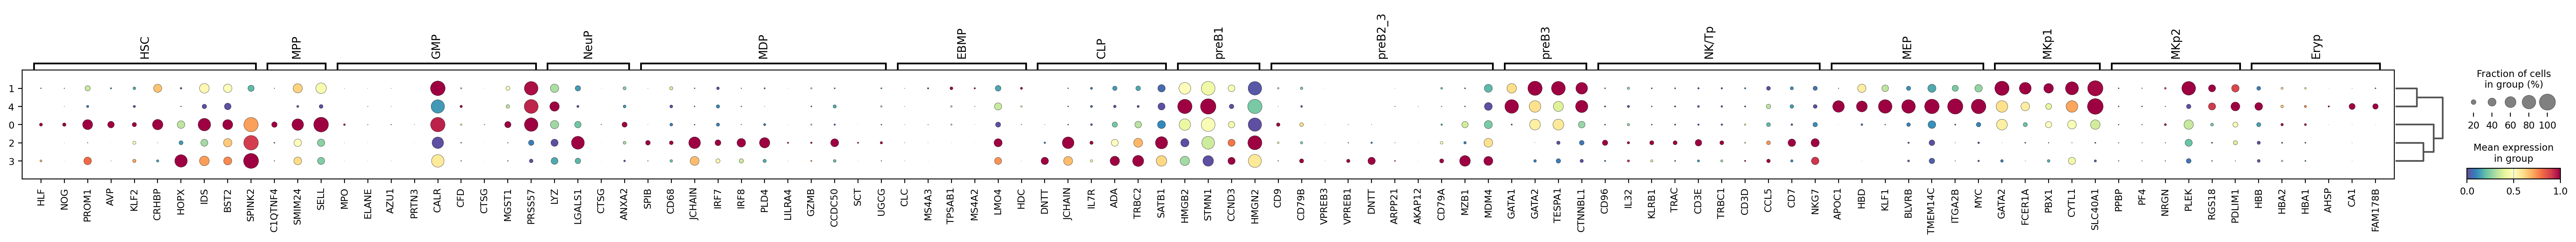

In [634]:
sc.pl.dotplot(adata, genes_to_check,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
              save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [635]:
tfs_to_check ={
'HSC|MPP': ['AVP','KLF2','CRHBP','HOPX','BST2','SPINK2','MECOM','HOXA7','HOXA3','HESX1'],
'GMP|NeuP': ['CEBPA','ASCL2','CEBPD','CEBPE'],
'MDP': ['IRF7','SPIB','IRF4'],
'EBMP': ['POU2F2','GATA2','IKZF2','MEIS2','MITF'],
'CLP': ['MAFK','MEF2A',],
'preB1': ['E2F7','E2F8','E2F2'],
'preB2|3': ['BACH2','TCF3','FOXO1','EBF1','PAX5'],
'NK/Tp': ['RORA','EOMES','TBX21','BCL11B'],
'MEP|MKp1|MKp2|Eryp': ['GFI1B','GATA1','NFIB','HES5','PPARA'],
}
#Deciphering transcriptome alterations in bone marrow hematopoiesis at single-cell resolution in immune thrombocytopenia. Signal Transduct Target Ther 2022 Oct 7;7(1):347. PMID: 36202780

In [ ]:
sc.pl.dotplot(adata, tfs_to_check,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
#基因集富集NK
sc.tl.score_genes(adata,['IL2RB','IRF8','JAK1','NKG7','PLEK','ZEB2','EOMES','GZMA','PRF1',])
sc.pl.umap(adata, color='score',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.dotplot(adata, ['CD7','CD3D','CD4','CD8A','CCR6','CD34','TBX21','EOMES',
                      'AHR','KIT','IL7R','ID2','ZBTB16','RORC','PTGDR2','GATA3','HLA-DRA','NCR3',
                      'JCHAIN','NFIL3','KLRD1','KLRB1','CD27','NCAM1','KLRG1','XCL1','XCL2','ITGA4','TNFRSF4',
                      'NCR1','NCR2','NCR3','TOX','RUNX1','EOMES','FLT3','ACY3','IL2RB',
                      'FTH1','AHNAK','S100A6','S100A4','KLRB1','CRIP1','MAF',
                      'RORA','PDCD4','IL10RA','STAT4','TYROBP',
                      'IRF1','ZFP36','ITGB1','CD69','NFKBIA','TNFAIP3',
                            'TPM3','NFKB1','PREX1','UBC','EEF2','CD44','CLEC4C','HMGB1','MEF2A','IL1R1','IRF7','CD79A','CD96','MS4A3'],
              standard_scale='var',groupby=groupby)

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='AVP',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CRHBP',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'ITGA6',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD14',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='IL7R',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='KIT',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='MPL',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'SPI1',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'GATA2',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'CD38',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adata,'CD34',groupby=groupby,show=False, ax=axs[1,3],size=0.5)
plt.show()
# PU.1/  CD71/ HBD MYB IL1B ITGA2B-low ALDH1A1 ST8SIA6 GMPR TPO MPL=CD110+ FLT3low GATA1 血红素代谢 CD45RA-

In [ ]:
sc.pl.violin(adata,'FCER1A',groupby=groupby)

In [178]:
#KEGG_HEMATOPOIETIC_cell_Lineage的富集查看
#除了4和6，lin neg
cell_dict = {
    'MEP':['4'],#CD45RA-CD7- CD34+ SPINK2- MPL=CD110+ FLT3=CD135- HBD  CSF3R+ FCER1A+ RUNX1+ CD38+确认 PLEK- PF4- KIT 'APOC1','HBD','KLF1','BLVRB','TMEM14C','ITGA2B','MYC'
    'MkP':['1'],#CD45RA-CD7- CD34+ SPINK2- MPL=CD110+ FLT3=CD135- HBD  CSF3R+ FCER1A+ RUNX1+ CD38+确认 PLEK+ PF4-  'GATA2','FCER1A','PBX1','CYTL1','SLC40A1'
    'CLP':['3',],#CD45RA+ CCR7 CCR9 CD7- IL7R- CD34+ SPINK2+ SOX4- KIT- DNTT+ FLT3+ LMO4+ MME+ CCR7+ RUNX2+ CD79Alow VPREB1low JCHAIN+ ITGA6low CD38- 
    'HSC/MPP':['0',],#CD45RA- AVP+ GATA2+ RUNX1+ FCER1A+
    'CILCP':['2',],#CD45RA+ CD34- KIT+ NFIL3+ TOX+ ITGAX+ TCF7+ RORC+ IL7R- CD3E+ AHR+  CD27- HLA-DR+ CD122=IL2RB-(核心，表明不是NKP) TBX21- EOMES- ITGAM+ GATA3- ID2+
    }

# https://www.cell.com/immunity/fulltext/S1074-7613(18)30246-2  CILCP

#CD7- 	CD34+ CD133+ SPI1 MYB MPL=CD110+ CSF3R=G-CSFR+  CD45RA-
#'Circulating MEPs'
#CD34+ CD38+ CD123- FLT3=CD135+ CD45RA-   CD38-low  AVP 
#'Circulating MkPs'#megakaryocyte  progenitor cells  PLEK

#CD7low CD34-  KIT+ CD133- FLT3=CD135+ PLD4  SPIB SPI1+(出骨髓的) CD45RA- IL7R- LMO4 MHCII+
#'Circulating MDPs'#common dendritic cell progenitors
#CCR7 RUNX2  JCHAIN   IGHM IGHD SOX4 GATA1- CD38- RORC

#CD7- 	CD34+  CD133+ KIT- FLT3=CD135+ PU.1/SPI1+(出骨髓的) MME CD45RA- IL7R-  ADA 
#'Circulating CLPs'
#CCR7  RUNX2  JCHAIN DNTT/tdt  IGHM IGHD SOX4 GATA1- CD38- LMO4

#Lin- CD7+ KIT+ CD96+ IL7R+ SELPLG+(CLP前往胸腺的因子) CD45RA+  SOX4-  FLT3=CD135-  CXCR4low SELL
#'Circulating NK/TPs'
#TCF7 IL32 ETS1（表明已经过了CLP阶段）  IL2RA=CD25+
#ILC2表达GATA3,但是需要KIT-/CRTH2+,所以不是
#ILC3需要RORC和AHR+，不是

#CXCR2/CXCL8促进出骨髓，CXCR4抑制出骨髓
# ATXN1（SCA1）
#T-restricted progenitors, circulating T progenitors, T-committed precursors PMID: 21251013, PMID: 17222572
#GMP 需要MPO
#https://www.nature.com/articles/s41392-022-01167-9 STTT
#https://www.nature.com/articles/s41467-022-29675-w    CD34+EPCR(PROCR)+(CD38/CD45RA)−   CD34+CD38−CD45RA− HSC    CD90+CD49f(ITGA6)+ HSC and CD90−CD49f− MPPs      CD90+CD49f+ and CD90−CD49f+ HSC
#https://www.cell.com/cell/fulltext/S0092-8674(24)00408-2#author-highlights-abstract MEP  AVP
#https://www.bdbiosciences.com/content/dam/bdb/marketing-documents/BD_Multiparametric_Immuno_Stem_Cells_AppNote.pdf
#https://link.springer.com/article/10.1007/s00018-018-2865-1#Sec3 NK ILC问题
# From stem cell to T cell: one route or many? 
# 血液中 HSC 的频率随昼夜节律振荡而波动，在光明开始后 5 小时达到峰值，在天黑后至少 5 小时达到峰值。我们在早上取样的（PMID: 18256599）
#  Exacting experiments to uncover the mechanisms of lymphoid progenitor homing from the BM to the thymus have been hampered by difficulties in identifying the relevant progenitor population

In [179]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
0    6807
3    5592
1    4781
2    1540
4     207
Name: count, dtype: int64

In [180]:
check_dict_duplicates(cell_dict)

'无重复'

In [181]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [182]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
HSC/MPP    6807
CLP        5592
MkP        4781
CILCP      1540
MEP         207
Name: count, dtype: int64

In [183]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0589_Rep1_GCTAACGA_AGCACCTC_AACGTGAT,HSPC,HSPC,HSC/MPP,HSPC c0,NaN,NaN,0.382480,8.615336
D0589_Rep1_CCTAATCC_AGCAGGAA_TCCGTCTA,HSPC,HSPC,MkP,HSPC c1,NaN,NaN,-0.429581,4.597815
D0589_Rep1_AAACATCG_AAGACGGA_AACGTGAT,HSPC,HSPC,MkP,HSPC c1,NaN,NaN,-1.115641,5.369998
D0589_Rep1_AGTCACTA_ATTGGCTC_AGCAGGAA,HSPC,HSPC,CILCP,HSPC c2,NaN,NaN,10.349859,5.813911
D0589_Rep1_CCATCCTC_AACTCACC_AAACATCG,HSPC,HSPC,MkP,HSPC c1,NaN,NaN,-2.434783,5.852609


# 3. 定 NaiveB Cell Refine

In [35]:
celltype="NaiveB"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [36]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [38]:
groupby = "L3_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [430]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD27',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='IGHM',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='IGHD',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'IGHM',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'IGHD',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'CD27',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'CD1C',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
#atypical B
sc.pl.dotplot(adata, ['SIGLEC6','ITGAX','PTPRS','ZBTB32','SOX5','IGHG1',
                      'SYT1','MX1','SHISA8','LGMN','TOX2','IGHG4','PALS2','CD86','GPR137B','SEMA7A','FCRL5',
                     'LILRB2','TOX','ENC1','TNFRSF1B'],
              standard_scale='var',groupby=groupby)

In [ ]:
#Transitional MME, CD9, CD38, PAX5, and FCER2
sc.pl.dotplot(adata, ['MME','CD38','CD9','FCER2','PAX5','BACH2',
    'TNFRSF13C','CD24','FCRL4','CD180','IL2RA',
                      
                      'CD93','IL7R','IL4R','FAS','NOTCH2',
                      'FOXO1','IKZF1','IKZF3','TCF3',
                      'EBF1','SSBP2','BACH2','PRKCE','RUNX1','BCL2','POU2F2','BCL6',
                      'CD1C','CD1D','CD5','ZBTB16','CR2','CR1',
                     'CTLA4','TFRC'],
              standard_scale='var',groupby=groupby)

In [ ]:
#Type 2 polarized memory B cell: IL4R, FCER2, COCH, IGHG1, IGHG4, and IGHE. IGHE
# early memory: CD27, AIM2 and class-switched isotype IgH (IGHA1, IGHA2 and IGHG1, IGHG2, IGHG3, and IGHG4). ‘Intermediate’
# Activated memory cell

sc.pl.dotplot(adata, ['COCH','IL4R','FCER2','IGHG1','IGHG2','IGHG3','IGHG4',
                      'IGHE','IL13RA1','RNGTT','PDE4D','SELL','EAF2','FCGR2B','CXCR3','CCR7',
                      'ITGAX',
                     'AIM2','CD27','IGHA1','IGHA2','ENTPD1','LAIR1','CD72',
#DEG                     
                     'NT5E','AREG','ITGB1','MS4A1','FAS','JUN','FOS','MCL1','MYC','CTLA4','TNFRSF8','IL7',],
              standard_scale='var',groupby=groupby)

In [ ]:
sc.pl.violin(adata,'SPIB',groupby=groupby,size=0)

In [39]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
2    346149
6    188577
0    184475
4    177128
1    127405
5     77368
9     45675
8     40737
3     39692
7      5580
Name: count, dtype: int64

In [40]:
cell_dict = {
             #Naïve B,TCL1A, IL4R,FCER2,. CD19+, CD20+, CD27-, IgD+, IgM+,
             'Naïve B':['1','2','3','4','5','6',],
             #CD27+, IgDlo, IgM +
             'Memory B':['0',],#AIM2 CD27 IGHG4 IGHG1 IGHG2; Intermediate B; 
    
             'Doublet|Lowquality':['7',#NK/T 报NK/Tp,回顾non-nk ILC的，有相似但不同
                        '8'#ADT
                                   '9'
                       ],#
            }

#https://www.cellsignal.cn/pathways/immune-cell-markers-human
#https://www.abcam.cn/primary-antibodies/b-cells-basic-immunophenotyping
#https://www.bdbiosciences.com/zh-cn/learn/research/immunology/b-cells#B-Cell-Immunophenotyping
#https://ashpublications.org/blood/article/114/25/5173/26511/An-in-vitro-model-of-differentiation-of-memory-B
#浆细胞、浆母细胞https://www.sohu.com/a/234622412_610701;
#https://zhuanlan.zhihu.com/p/56657003
#https://www.biocompare.com/Editorial-Articles/570578-A-Guide-to-B-Cell-Markers/
# https://www.cell.com/trends/immunology/fulltext/S1471-4906(22)00003-5#secst0040
# https://www.nature.com/articles/s41577-024-00991-0

# IgD的出现，意味着B细胞从原先耐受抗原的细胞，开始逐渐转变为可对抗原产生反应的B细胞了，
# 所以从T1、T2、T3开始IgD逐渐增高，到Naive达到高峰。当Naive刚变成Memory B时，IgD仍保留着，所以此时叫Unswitched（未转换），
# 只有Memory B的表面Ig从IgD转变为IgG、IgA或IgE时，才叫Switched Memory B
# ，就可以进一步向Plasmablast（浆母细胞）转换，开始大量分泌抗体。

In [41]:
check_dict_duplicates(cell_dict)

'无重复'

In [42]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [43]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    1232786
Name: count, dtype: int64

In [44]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Naïve B               1001994
Memory B               184475
Doublet|Lowquality      46317
Name: count, dtype: int64

In [45]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [46]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Naïve B     1001994
Memory B     184475
Name: count, dtype: int64

In [47]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R2_refine_indices_{celltype}.csv")

# 5. 定 Meomory BCell Refine

In [30]:
celltype="MemoryB"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [31]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [32]:
groupby = "L3_leiden_TOTALVI_1.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [100]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD27',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='IGHM',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='IGHD',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'IGHM',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'IGHD',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'CD27',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'CD1C',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
sc.pl.umap(adata, color='FCER2',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
#atypical B
sc.pl.dotplot(adata, ['SIGLEC6','ITGAX','PTPRS','ZBTB32','SOX5','IGHG1',
                      'SYT1','MX1','SHISA8','LGMN','TOX2','IGHG4','PALS2','CD86','GPR137B','SEMA7A','FCRL5',
                     'LILRB2','TOX','ENC1','TNFRSF1B','FGR'],
              standard_scale='var',groupby=groupby)

In [ ]:
#Transitional MME, CD9, CD38, PAX5, and FCER2
sc.pl.dotplot(adata, ['MME','CD38','CD9','FCER2','PAX5','BACH2',
    'TNFRSF13C','CD24','FCRL4','CD180','IL2RA',
                      
                      'CD93','IL7R','IL4R','FAS','NOTCH2',
                      'FOXO1','IKZF1','IKZF3','TCF3',
                      'EBF1','SSBP2','BACH2','PRKCE','RUNX1','BCL2','POU2F2','BCL6',
                      'CD1C','CD1D','CD5','ZBTB16','CR2','CR1',
                     'CTLA4','TFRC'],
              standard_scale='var',groupby=groupby)

In [ ]:
#Type 2 polarized memory B cell: IL4R, FCER2, COCH, IGHG1, IGHG4, and IGHE.
# early memory: CD27, AIM2 and class-switched isotype IgH (IGHA1, IGHA2 and IGHG1, IGHG2, IGHG3, and IGHG4). ‘Intermediate’
# Activated memory cell

sc.pl.dotplot(adata, ['COCH','IL4R','FCER2','IGHG1','IGHG2','IGHG3','IGHG4',
                      'IGHE','IL13RA1','RNGTT','PDE4D','SELL','EAF2','FCGR2B','CXCR3','CCR7',
                      'ITGAX',
                     'AIM2','CD27','IGHA1','IGHA2','ENTPD1','LAIR1','CD72',
#DEG                     
                     'NT5E','AREG','ITGB1','MS4A1','FAS','JUN','FOS','MCL1','MYC','CTLA4','TNFRSF8','IL7',],
              standard_scale='obs',groupby=groupby)

In [ ]:
sc.pl.dotplot(adata, ['BTBD9',],
              standard_scale='var',groupby=groupby)

In [ ]:
adata.obs['cluster_dummy'] = adata.obs[groupby] == adata.obs[groupby].cat.categories[12]
sc.pl.umap(adata, color='cluster_dummy',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [116]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_1.5
1     71172
10    68699
11    64612
9     63834
2     61686
13    54936
14    50825
6     49921
3     43114
4     37766
12    25840
8     19140
15    18762
0     12739
16    10981
5      9708
19     9145
7      6805
20     6376
17     5168
18     3165
21      199
Name: count, dtype: int64

In [52]:
cell_dict = {
             'Atypical memory B':['2','16','20','21'],#IL4R-FCER2-
    
             #'Type 2 polarized memory B':[''],#看不到COCH+ IL4Rhi FCER2hi
    
             'Memory B':['0',#TBX21-
                         '1','3','4','5','6','9','10','11','14','13'],#
    
    'Naïve B':['7','15','19',],
    
             'Doublet|Lowquality':['8',#ADT
                                   '18',#NK
                                   '17',#T
                                   '12',
                       ],#
            }

#https://www.cellsignal.cn/pathways/immune-cell-markers-human
#https://www.abcam.cn/primary-antibodies/b-cells-basic-immunophenotyping
#https://www.bdbiosciences.com/zh-cn/learn/research/immunology/b-cells#B-Cell-Immunophenotyping
#https://ashpublications.org/blood/article/114/25/5173/26511/An-in-vitro-model-of-differentiation-of-memory-B
#浆细胞、浆母细胞https://www.sohu.com/a/234622412_610701;
#https://zhuanlan.zhihu.com/p/56657003
#https://www.biocompare.com/Editorial-Articles/570578-A-Guide-to-B-Cell-Markers/
# https://www.cell.com/trends/immunology/fulltext/S1471-4906(22)00003-5#secst0040
# https://www.nature.com/articles/s41577-024-00991-0

# IgD的出现，意味着B细胞从原先耐受抗原的细胞，开始逐渐转变为可对抗原产生反应的B细胞了，
# 所以从T1、T2、T3开始IgD逐渐增高，到Naive达到高峰。当Naive刚变成Memory B时，IgD仍保留着，所以此时叫Unswitched（未转换），
# 只有Memory B的表面Ig从IgD转变为IgG、IgA或IgE时，才叫Switched Memory B
# ，就可以进一步向Plasmablast（浆母细胞）转换，开始大量分泌抗体。

In [53]:
check_dict_duplicates(cell_dict)

'无重复'

In [54]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [55]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    694593
Name: count, dtype: int64

In [56]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Memory B              527326
Atypical memory B      79242
Doublet|Lowquality     53313
Naïve B                34712
Name: count, dtype: int64

In [57]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [58]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Memory B             527326
Atypical memory B     79242
Naïve B               34712
Name: count, dtype: int64

In [59]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R2_refine_indices_{celltype}.csv")

# 6. 定 终Plasma Cell Refine

In [184]:
celltype="Plasma"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [185]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [186]:
groupby = "L3_leiden_TOTALVI_0.5"

In [15]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [17]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD27',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='IGHM',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='IGHD',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'IGHM',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'IGHD',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'CD27',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'CD1C',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
#atypical B
sc.pl.dotplot(adata, ['SIGLEC6','ITGAX','PTPRS','ZBTB32','SOX5','IGHG1',
                      'SYT1','MX1','SHISA8','LGMN','TOX2','IGHG4','PALS2','CD86','GPR137B','SEMA7A','FCRL5',
                     'LILRB2','TOX','ENC1','TNFRSF1B'],
              standard_scale='var',groupby=groupby)

In [ ]:
#Transitional MME, CD9, CD38, PAX5, and FCER2
sc.pl.dotplot(adata, ['MME','CD38','CD9','FCER2','PAX5','BACH2','NEIL1','SOX4','VPREB3',
    'TNFRSF13C','CD24','FCRL4','CD180','IL2RA',
                      
                      'CD93','IL7R','IL4R','FAS','NOTCH2',
                      'FOXO1','IKZF1','IKZF3','TCF3',
                      'EBF1','SSBP2','BACH2','PRKCE','RUNX1','BCL2','POU2F2','BCL6',
                      'CD1C','CD1D','CD5','ZBTB16','CR2','CR1',
                     'CTLA4','TFRC'],
              standard_scale='obs',groupby=groupby)

In [ ]:
#Type 2 polarized memory B cell: IL4R, FCER2, COCH, IGHG1, IGHG4, and IGHE. IGHE
# early memory: CD27, AIM2 and class-switched isotype IgH (IGHA1, IGHA2 and IGHG1, IGHG2, IGHG3, and IGHG4). ‘Intermediate’

sc.pl.dotplot(adata, ['COCH','IL4R','FCER2','IGHG1','IGHG2','IGHG3','IGHG4',
                      'IGHE','IL13RA1','RNGTT','PDE4D','SELL','EAF2','FCGR2B','CXCR3','CCR7',
                      'ITGAX',
                     'AIM2','CD27','IGHA1','IGHA2','ENTPD1','LAIR1','CD72',
#DEG                     
                     'NT5E','AREG','ITGB1','MS4A1','FAS','JUN','FOS','MCL1','MYC','CTLA4','TNFRSF8','IL7',],
              standard_scale='obs',groupby=groupby)

In [ ]:
sc.pl.dotplot(adata, ['BTBD9','ZBTB20','ANK3',#低质量细胞
                     'IGLL5','IGKC','CXCR4','CD83','CCR6','PRDM1','LAG3','CXCR3',
                      'MKI67','STMN1','CD5','CRIP1','FGR','CIB1','CD38','PAX5','CD40'
                     ],
              standard_scale='obs',groupby=groupby)

In [187]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
1    17237
2    11184
4     5165
3     4410
0     3384
5     3091
7     2602
8      897
6      663
Name: count, dtype: int64

In [188]:
cell_dict = {'CD95 memory B cells':['5',],
             #FCER2+ ENTPD1+ CD69+ CCR7+ COCH+ IGE+ IL4R+  CCR7+ 跟atypical很像的群体,但atypical IL4R-FCER2-；
             #且 Type2 polarized memory B cell 是和atypical完全不像的[Type 2–polarized memory B cells hold allergen-specific IgE memory]
             
             'IGLL5hi Plasma cells':['0',],#正常成熟浆细胞通常不表达替代轻链，但在某些病理状态中可能异常表达。
             #Antibody-Secreting Cells: IgD-,IgM-，CD27+,CD20-
             'IGKChi Plasma cells':['1','2','6'],#CD38 #IGKC 正常成熟浆细胞通
             'Plamsablasts':['3'],#
             'Doublet|Lowquality':['4',#Neu
                        '7',#BTBD9 ZBTB20
                        '8',#T
                       ],#
            }

# CD45RB+ Activated has higher expression of CD21, CXCR5, CD27, CD95, 
# and was confirmed by direct comparison with CD45RB+CD27+ memory by its significantly 
# lower expression of CD21, CXCR5, CXCR4 and CD24 alongside significantly increased CD11c, CD39, CD71, CD38, CD95, Ki67 and CD19

#Type 2 polarized memory B cell=MBC2
# two clusters of that highly express markers associated with type 2 immunity. The unifying features were a high expression of  CD23 (FCER2) and  IL-4 (IL4R) and IL-13 (IL13RA1). 
# The two MBC2 clusters: IGHE+ MBC2s, the absence of IGHE and greater CD69 expression in the other (IGHE− MBC2s). When IGHE was not considered in the clustering analysis, these two populations coclustered,
# suggesting that they are transcriptionally related. 
# (i) IGHM+ IGHD+ CD27− cells, naïve B cells;
# (ii)  high expression of CD19, ITGAX (CD11c), and FCRL5, which are referred to as atypical B cells “CD19hi CD11chi”
# (iii) CD95+ FAS+ (CD95), ITGB1+ (CD29), NT5E+ (CD73) cells denoted as “CD95+”;
# (iv)  AREG, CDKN1A, and NFKB1, a phenotype similar to that reported by bulk RNA sequencing of citrullinated peptide-specific B cells
# !! CD19hi CD11chi MBCs had the greatest Euclidean distance to any other MBC subset and shared the expression of very few differentially expressed genes with the MBC2

#https://www.cellsignal.cn/pathways/immune-cell-markers-human
#https://www.abcam.cn/primary-antibodies/b-cells-basic-immunophenotyping
#https://www.bdbiosciences.com/zh-cn/learn/research/immunology/b-cells#B-Cell-Immunophenotyping
#https://ashpublications.org/blood/article/114/25/5173/26511/An-in-vitro-model-of-differentiation-of-memory-B
#浆细胞、浆母细胞https://www.sohu.com/a/234622412_610701;
#https://zhuanlan.zhihu.com/p/56657003
#https://www.biocompare.com/Editorial-Articles/570578-A-Guide-to-B-Cell-Markers/
# https://www.cell.com/trends/immunology/fulltext/S1471-4906(22)00003-5#secst0040
# https://www.nature.com/articles/s41577-024-00991-0

# IgD的出现，意味着B细胞从原先耐受抗原的细胞，开始逐渐转变为可对抗原产生反应的B细胞了，
# 所以从T1、T2、T3开始IgD逐渐增高，到Naive达到高峰。当Naive刚变成Memory B时，IgD仍保留着，所以此时叫Unswitched（未转换），
# 只有Memory B的表面Ig从IgD转变为IgG、IgA或IgE时，才叫Switched Memory B
# ，就可以进一步向Plasmablast（浆母细胞）转换，开始大量分泌抗体。

In [189]:
check_dict_duplicates(cell_dict)

'无重复'

In [190]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [191]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    48633
Name: count, dtype: int64

In [192]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
IGKChi Plasma cells     29084
Doublet|Lowquality       8664
Plamsablasts             4410
IGLL5hi Plasma cells     3384
CD95 memory B cells      3091
Name: count, dtype: int64

In [193]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [194]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
IGKChi Plasma cells     29084
Plamsablasts             4410
IGLL5hi Plasma cells     3384
CD95 memory B cells      3091
Name: count, dtype: int64

In [195]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0589_Rep1_ACAAGCTA_GAACAGGC_GAGCTGAA,B|Plasma,Plasma,IGLL5hi Plasma cells,Plasma c0,NaN,BCR,-4.993308,5.252944
D0589_Rep1_CTGAGCCA_AAGACGGA_GGTGCGAA,B|Plasma,Plasma,Plamsablasts,Plasma c3,NaN,BCR,1.880042,2.680106
D0589_Rep1_GATAGACA_CAGATCTG_CGCATACA,B|Plasma,Plasma,IGLL5hi Plasma cells,Plasma c0,NaN,BCR,-5.573255,4.916696
D0589_Rep1_CCGAAGTA_CGCTGATC_GAGTTAGC,B|Plasma,Plasma,CD95 memory B cells,Plasma c5,NaN,BCR,9.161488,5.875019
D0589_Rep1_AGTCACTA_AGTACAAG_TGGTGGTA,B|Plasma,Plasma,IGKChi Plasma cells,Plasma c2,NaN,BCR,2.770410,7.970550


# 7. 定 Naïve CD4+ T Cell Refine

In [13]:
celltype="NaiveCD4"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [14]:
adata,adt,leiden_data = get_annotation_data(celltype)

... storing 'Celltype_L1_L2' as categorical
... storing 'Celltype_L1_L2_Refine' as categorical
... storing 'receptor_type' as categorical


In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [15]:
groupby = "L3_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [194]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 5000,
                                                 by = groupby,
                                                 return_index = True,random_state=0)

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata[cell_index], keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata[cell_index], keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata[cell_index], keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata[cell_index], keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata[cell_index], keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[0,1],size=0,layer='clr')
sc.pl.umap(adata, color='CCR4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CCR10',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,0],show=False)
sc.pl.umap(adata, color='CXCR5',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,1],show=False)
sc.pl.umap(adata, color='CXCR3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,2],show=False)
sc.pl.umap(adata, color='CCR6',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,3],show=False)
plt.show()

In [ ]:
sc.pl.umap(adata, color='FOXP3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
adata.obs['cluster_dummy'] = adata.obs['L3_leiden_TOTALVI_1'] == adata.obs['L3_leiden_TOTALVI_1'].cat.categories[2]
sc.pl.umap(adata, color='cluster_dummy',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [20]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
4    915508
3    725907
0    540330
1    528453
2     88033
Name: count, dtype: int64

In [ ]:
#Tfh CD185 (CXCR5) CD183 (CXCR3) CD278 (ICOS) CD279 (PD1)
sc.pl.dotplot(adt, ['CD185','CD183','CD278','CD279','CD27','CD25',
                      ],
              standard_scale='obs',groupby=groupby)

In [ ]:
#CD45RA- CD27+ KLRB1lo CCR7+ SELL+ IL6R+ TBX21+ CD25-/lo CCL5- GZMH- GZMK- GNLY- PRF1- GZMB-  的是Tfh，但是ICOS=CD278+、CXCR5+、CD279+、TIGIT+
sc.pl.dotplot(adata, ['CXCR5','KLRB1','CCR4','TCF7','ICOS','CD27','CXCR3','PDCD1','TBX21','IL6R','TIGIT',
                      'CCL5','GZMK','CTLA4'#阴性指标
                      ],
              standard_scale='obs',groupby=groupby)

In [ ]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','KLRB1','GZMK','CCL5','BTBD9','CXCR3','GATA3','CCR10',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','TRDV1'],
              standard_scale='obs',groupby=groupby)

In [18]:
#Naïve CD4+ T 需要CD45RA+ CCR7=CD197hi CD62Lhi
# effector memory T cells(TEM, CD45RA-/CCR7-)
# TEMRA cells, which are T cells that re-express CD45RA(CD45RA+/CCR7-)

cell_dict = {'Doublet|Lowquality':['2',],#
             #CD45RA+ CCR7=CD197hi CD62Lhi
             'Naïve CD4+ T':['3','4'],

             #CD45RA- CCR7int ITGB1
             'Helper memory CD4+ T':['1'],#CXCR5 KLRB1 SELL+ CCL5-
             
             #需要CD45RA+ CCR7=CD197hi CD62Lhi
             'Naïve CD8+ T':['0',],#
            }

#CXCR3=CD183

In [19]:
check_dict_duplicates(cell_dict)

'无重复'

In [20]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [21]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    2798231
Name: count, dtype: int64

In [23]:
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_1']=='1','Celltype_L2_L3_Refine']='Treg'#初始T激活，上调了CD25,和Treg混合

In [24]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Naïve CD4+ T            1600883
Naïve CD8+ T             540027
Treg                     321408
Helper memory CD4+ T     247962
Doublet|Lowquality        87951
Name: count, dtype: int64

In [26]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [27]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Naïve CD4+ T            1600883
Naïve CD8+ T             540027
Treg                     321408
Helper memory CD4+ T     247962
Name: count, dtype: int64

In [28]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R2_refine_indices_{celltype}.csv")

# 8. 定 Treg Cell Refine

In [84]:
celltype="Treg"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [85]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [87]:
groupby = "L3_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [133]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False,layer='denoised_protein')
sc.pl.umap(adt, color='CD45RA',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='FOXP3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,0],show=False)
sc.pl.umap(adata, color='PDCD1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,1],show=False)
sc.pl.umap(adata, color='TIGIT',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,2],show=False)
sc.pl.umap(adata, color='IL2RA',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,3],show=False)
plt.show()

In [ ]:
sc.pl.umap(adata, color='MKI67',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.dotplot(adata, ['ISG15','CD160','KLRD1','IL2RA','CTLA4','FOXP3','FCRL3','CCR10','RORC','KLRB1','HLA-DRB1',
                     'HAVCR2'],
              standard_scale='var',groupby=groupby)

In [ ]:
sc.pl.dotplot(adata, ['CD40LG','CCR4','CCR6','CXCR5','KLRB1','GZMK','CCL5','BTBD9','CXCR3',
                      'GATA3','CCR10','LIMS1','RORC','CD27','CCR1','CCR2','PRDM1'],
              standard_scale='var',groupby=groupby)

In [ ]:
sc.pl.violin(adata, 'FOXP3',groupby=groupby,size=0.1)

In [88]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
4    82177
3    72362
1    66250
2    42921
0    20295
5     4052
Name: count, dtype: int64

In [89]:
#Naïve CD4+ T 需要CD45RA+ CCR7=CD197hi CD62Lhi
# effector memory T cells(TEM, CD45RA-/CCR7-)
# TEMRA cells, which are T cells that re-express CD45RA(CD45RA+/CCR7-)

#IRF4- TGFB1+ CXCR4lo 
cell_dict = {
             'Treg':['1',#Treg Naive KLRB1lo
                     '2',#GZMK CCL5 KLRB1 它起始时CD4 Tem，表达和Treg相似
                     '3',#Treg
                     '4',#Treg
                     '5',#CD8Treg
                    ],
             'Proliferative T':['0'],#CD38 MKI67
            }

#Single-cell atlas of healthy human blood unveils agerelated loss of NKG2C+GZMB–CD8+ memory T cells and accumulation of type 2 memory T cells

#naïve (CD45RApos), memory (CD45RAnegCD73neg), TR1‐like (CD73pos), and activated (HLA‐DRposCD39pos). 

In [90]:
check_dict_duplicates(cell_dict)

'无重复'

In [91]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [92]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    288057
Name: count, dtype: int64

In [93]:
#结合多个leiden维度注释
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_1']=='0','Celltype_L2_L3_Refine']='Proliferative T'
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_1']=='4','Celltype_L2_L3_Refine']='Proliferative T'

In [94]:
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_2']=='20','Celltype_L2_L3_Refine']='Tem CD8+ T'

In [95]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Treg               256640
Proliferative T     25735
Tem CD8+ T           5682
Name: count, dtype: int64

In [ ]:
sc.pl.umap(adata, color='Celltype_L2_L3_Refine',legend_fontsize=4, 
           legend_fontoutline=2,size=1,legend_loc='on data',
           layer='denoised_protein')

In [97]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [98]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Treg               256640
Proliferative T     25735
Tem CD8+ T           5682
Name: count, dtype: int64

In [99]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R2_refine_indices_{celltype}.csv")

# 9. 定 Helper memory CD4+ T Cell Refine

In [70]:
celltype="CD4_helper_memory"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [71]:
adata,adt,leiden_data = get_annotation_data(celltype)

... storing 'Celltype_L1_L2' as categorical
... storing 'Celltype_L1_L2_Refine' as categorical
... storing 'receptor_type' as categorical


In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [72]:
groupby = "L3_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False,layer='denoised_protein')
sc.pl.umap(adt, color='CD45RA',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CCR4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CCR10',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,0],show=False)
sc.pl.umap(adata, color='CXCR5',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,1],show=False)
sc.pl.umap(adata, color='CXCR3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,2],show=False)
sc.pl.umap(adata, color='CCR6',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,3],show=False)
plt.show()

In [ ]:
sc.pl.umap(adata, color='FOXP3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
adata.obs['cluster_dummy'] = adata.obs['L3_leiden_TOTALVI_2'] == adata.obs['L3_leiden_TOTALVI_2'].cat.categories[1]
sc.pl.umap(adata, color='cluster_dummy',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [48]:
adata.obs['L3_leiden_TOTALVI_2'].value_counts()

L3_leiden_TOTALVI_2
24    505243
16    454993
6     440621
10    388758
12    362466
3     297001
0     278421
20    266083
4     263880
7     247534
14    208222
5     185831
13    164118
8     151511
1     150313
9      84542
25     31926
17     30949
19     13825
18      9402
2       6333
11      3053
22      1955
23       433
29       128
30       127
32        33
28        12
21        12
36         8
31         8
38         6
34         5
15         4
26         4
39         4
33         4
37         4
27         3
35         3
40         3
Name: count, dtype: int64

In [ ]:
sc.pl.umap(adata, color='TRDV1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.dotplot(adata, ['BTBD9','ANK3','ZBTB20',
                     'TRDV1',],
              standard_scale='var',groupby=groupby)

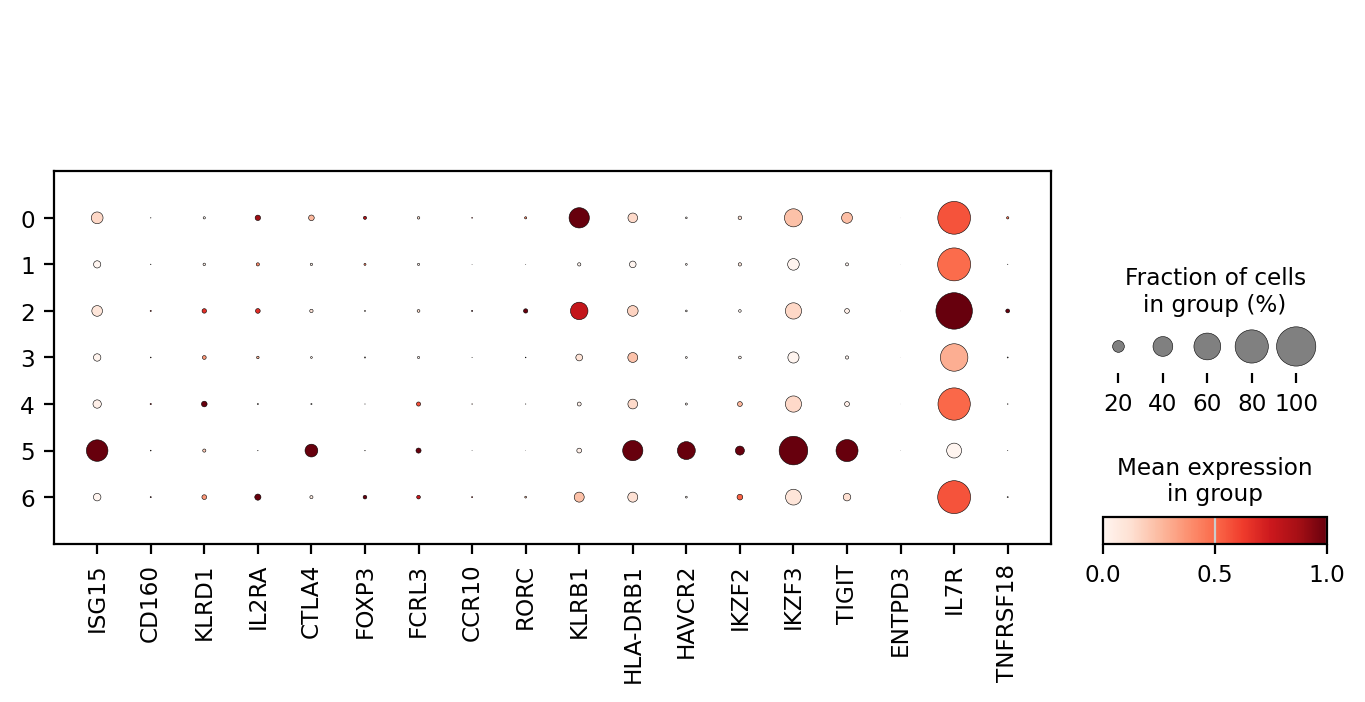

In [127]:
#Treg
sc.pl.dotplot(adata, ['ISG15','CD160','KLRD1','IL2RA','CTLA4','FOXP3','FCRL3','CCR10','RORC','KLRB1','HLA-DRB1',
                     'HAVCR2','IKZF2','IKZF3','TIGIT','ENTPD3','IL7R','TNFRSF18'],
              standard_scale='var',groupby=groupby)

In [ ]:
#Tfh CD185 (CXCR5) CD183 (CXCR3) CD278 (ICOS) CD279 (PD1)
sc.pl.dotplot(adt, ['CD185','CD183','CD278','CD279','CD27',
                    'CD25',#阴性指标
                      ],
              standard_scale='var',groupby=groupby)

In [ ]:
#CD45RA- CD27+ KLRB1lo CCR7+ SELL+ IL6R+ TBX21+ CD25-/lo CCL5- GZMH- GZMK- GNLY- PRF1- GZMB-  的是Tfh，但是ICOS=CD278+、CXCR5+、CD279+、TIGIT+
sc.pl.dotplot(adata, ['CXCR5','KLRB1','CCR4','TCF7','ICOS','CD27','CXCR3','PDCD1','TBX21','IL6R','TIGIT',
                      'CCL5','GZMK','CTLA4'#阴性指标
                      ],
              standard_scale='var',groupby=groupby)

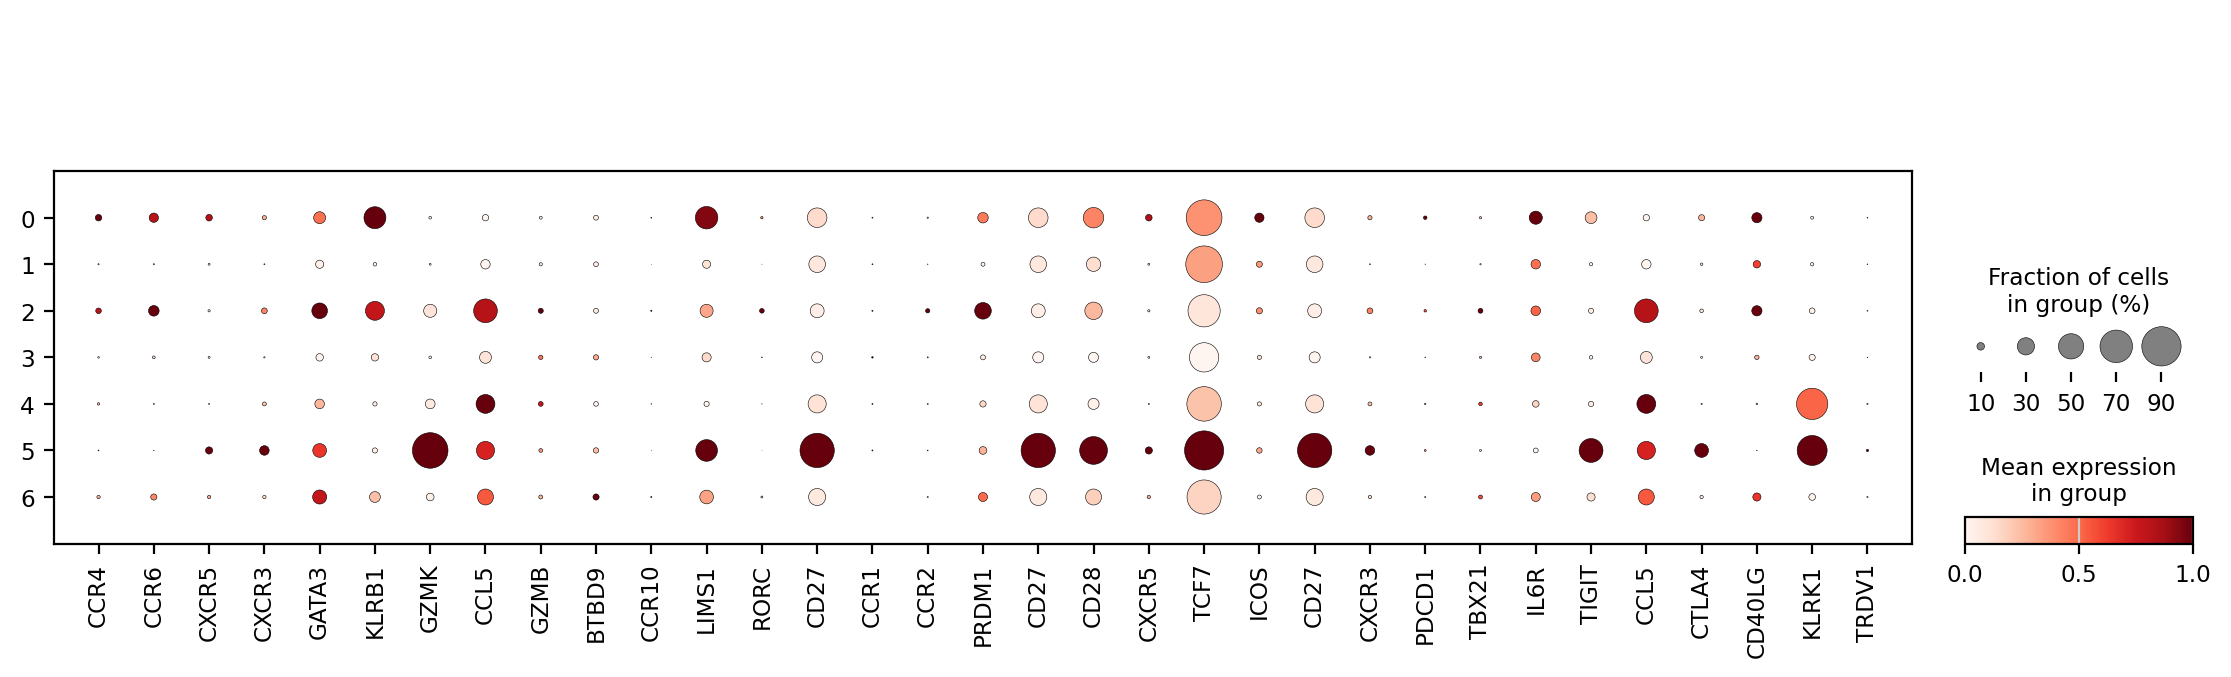

In [223]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','CXCR3','GATA3','KLRB1','GZMK','CCL5','GZMB','BTBD9','CCR10',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','CXCR5',
                      'TCF7','ICOS','CD27','CXCR3','PDCD1','TBX21','IL6R','TIGIT',
                      'CCL5','CTLA4','CD40LG','KLRK1','TRDV1'],
              standard_scale='var',groupby=groupby)

In [ ]:
adata.obs['cluster_dummy'] = adata.obs[groupby] == adata.obs[groupby].cat.categories[5]
sc.pl.umap(adata, color='cluster_dummy',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.violin(adata,'KLRB1',groupby=groupby,size=0.1)

In [73]:
#Naïve CD4+ T 需要CD45RA+ CCR7=CD197hi CD62Lhi
# effector memory T cells(TEM, CD45RA-/CCR7-)
# TEMRA cells, which are T cells that re-express CD45RA(CD45RA+/CCR7-)
cell_dict = {'Doublet|Lowquality':['3',
                                   '6',#BTBD9,ANK3,ZBTB20
                                  ],
            'Naïve CD4+ T':['1',],
            'Naïve CD8+ T':['4'],
            'Helper memory CD4+ T':['0','2',],

             'Dn T':['5'],
             'Treg':[],
             'Tem CD8+ T':[],
            }
#因为上一步的细胞身份错误，聚类结果本身不对

In [74]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
1    1665568
2    1373419
4     809550
0     541954
3     149580
5       7592
6        118
Name: count, dtype: int64

In [75]:
check_dict_duplicates(cell_dict)

'无重复'

In [76]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [77]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    4547781
Name: count, dtype: int64

In [78]:
#结合多个leiden维度注释
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_1']=='6','Celltype_L2_L3_Refine']='Tem CD8+ T'
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_1']=='9','Celltype_L2_L3_Refine']='Naïve CD8+ T'
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_2']=='1','Celltype_L2_L3_Refine']='Treg'
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_2']=='28','Celltype_L2_L3_Refine']='Treg'

In [79]:
#结合多个leiden维度注释
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_1']=='2','Celltype_L2_L3_Refine']='Doublet|Lowquality'#BTBD9,ANK3,ZBTB20
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_1']=='5','Celltype_L2_L3_Refine']='Doublet|Lowquality'#Neu
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_1']=='8','Celltype_L2_L3_Refine']='Doublet|Lowquality'#ADT
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_2']=='9','Celltype_L2_L3_Refine']='Doublet|Lowquality'#NK

In [ ]:
sc.pl.umap(adata, color='Celltype_L2_L3_Refine',legend_fontsize=4, 
           legend_fontoutline=2,size=1,legend_loc='on data',
           layer='denoised_protein')

In [81]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    4547781
Name: count, dtype: int64

In [82]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Helper memory CD4+ T    1552428
Naïve CD4+ T            1439800
Doublet|Lowquality       577662
Naïve CD8+ T             568496
Tem CD8+ T               255143
Treg                     146731
Dn T                       7521
Name: count, dtype: int64

In [83]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [84]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Helper memory CD4+ T    1552428
Naïve CD4+ T            1439800
Naïve CD8+ T             568496
Tem CD8+ T               255143
Treg                     146731
Dn T                       7521
Name: count, dtype: int64

In [85]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R2_refine_indices_{celltype}.csv")

# 10. 定 Cytotoxic CD4+ T Cell Refine

In [17]:
celltype="CytotoxicCD4"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [18]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [19]:
groupby = "L3_leiden_TOTALVI_2"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [182]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CCR4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CCR6',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
sc.pl.umap(adata, color='CTLA4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,0],show=False)
sc.pl.umap(adata, color='CD8A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,1],show=False)
sc.pl.umap(adt, color='CD45RA',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,2],show=False,layer='clr')
sc.pl.umap(adata, color='CD4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,3],show=False)
plt.show()

In [ ]:
sc.pl.umap(adata, color='FOXP3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.umap(adata, color='TRDV1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
adata.obs['cluster_dummy'] = adata.obs[groupby] == adata.obs[groupby].cat.categories[5]
sc.pl.umap(adata, color='cluster_dummy',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.violin(adata,'CXCL8',groupby=groupby,size=0.5)

In [ ]:
sc.pl.dotplot(
        adata,
        groupby=groupby,
        var_names=marker_dict1,
        dot_min=0.1,
        show=False
    )

In [171]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_2
0     130188
5     120983
18    102659
9      97337
16     95868
1      91976
14     90951
6      82796
7      82453
8      76916
13     74549
15     73295
10     66626
11     52934
12     50411
3      33006
2      15318
20      3347
4       1415
17      1415
22       508
24       294
25       132
30        43
27        38
21        26
23        23
29        21
37        20
33        17
31        17
35        15
26        14
28        14
34        11
46        11
41         8
40         8
19         7
32         7
43         7
45         7
38         6
36         6
42         6
39         4
44         4
47         4
48         4
49         3
50         3
Name: count, dtype: int64

In [ ]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','KLRB1','GZMK','CCL5','BTBD9','CXCR3','GATA3','CCR10',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28'],
              standard_scale='var',groupby=groupby)

In [ ]:
sc.pl.dotplot(adata, ['TRDV1','KLRF1','TIGIT','LAG3','PDCD1','HAVCR2','CTLA4','CD38','CCR5','FCGR3A','CD27','SELL','CCR7','IL7R','KLRF1','NCR1','CMC1',
                      'CCL5','TCF7','LEF1','SLC4A10','GZMK','KLRD1','KLRB1'],
              standard_scale='var',groupby=groupby)

In [316]:
cell_dict = {'Tcm CCR4+ CD8+ T':['2',],#GZMB-
             'Temra CD8+ T':['13',],#GZMB
             
             'Doublet|Lowquality':['4','25','36',#B
                                   '20','50',#NK
                                   '26','35','41','42','47','48',#FCGR3B/FCGR3A/CSF3R
                                   '49',#TRDV1 TRDV2
                                   '10',#ADT
                                   '21','23','27','28','29','30','31','32','33','34',#few cell in cluster
                                   '37','38','39','40',#few cell in cluster
                                   '43','44','45','46',#few cell in cluster
                                   '17',#Proliferative T 下游分析发现增殖状态是低质量的增殖细胞
                                  ],
             'Vδ2 T':['6',],
             'Helper memory CD4+ T':['5'],#CD279+ GZMK+ CCL5+ GZMB-
             'Th22':['0'],#CCR4+ CCR6+ KLRB1- GZMK- GATA3lo CCL5-
             'Th2':['1',],#CCR4+ CCR6- KLRB1- GATA3+ GZMK- CCL5-
             'Th1/Th17':['3'],#CCR6+ CCR4- KLRB1lo GZMK+ CCL5+
             
             'Cytotoxic CD4+ T':['7','8','9','11','12',#GZMB
                                 '14','15','16',#GZMB
                                 '18',#GZMB
                                 '19','22','24'],#
            }

In [317]:
check_dict_duplicates(cell_dict)

'无重复'

In [318]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [319]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    1345731
Name: count, dtype: int64

In [ ]:
sc.pl.umap(adata, color='Celltype_L2_L3_Refine',legend_fontsize=4, 
           legend_fontoutline=2,size=1,legend_loc='on data',
           layer='denoised_protein')

In [321]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Cytotoxic CD4+ T        723633
Th22                    130188
Helper memory CD4+ T    120983
Th2                      91976
Vδ2 T                    82796
Temra CD8+ T             74549
Doublet|Lowquality       71867
Th1/Th17                 33006
Tcm CCR4+ CD8+ T         15318
Proliferative T           1415
Name: count, dtype: int64

In [322]:
adata.obs.loc[(adata.obs['Celltype_L2_L3_Refine']=='Vδ2 T') & (adata.obs['receptor_type']=='TCR'),'Celltype_L2_L3_Refine']='Doublet|Lowquality'

In [323]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [324]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Cytotoxic CD4+ T        723633
Th22                    130188
Helper memory CD4+ T    120983
Th2                      91976
Temra CD8+ T             74549
Vδ2 T                    68156
Th1/Th17                 33006
Tcm CCR4+ CD8+ T         15318
Proliferative T           1415
Name: count, dtype: int64

In [325]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R2_refine_indices_{celltype}.csv")

# 11. 定 Naïve CD8+ T Cell Refine

In [129]:
celltype="NaiveCD8"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [130]:
adata,adt,leiden_data = get_annotation_data(celltype)

... storing 'Celltype_L1_L2' as categorical
... storing 'Celltype_L1_L2_Refine' as categorical
... storing 'receptor_type' as categorical


In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [132]:
groupby = "L3_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 5000,
                                                 by = groupby,
                                                 return_index = True,random_state=0)

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata[cell_index], keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata[cell_index], keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata[cell_index], keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata[cell_index], keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata[cell_index], keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [766]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD8A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='GZMK',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'KLRG1',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'PRF1',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'FCGR3B',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[1,3],size=0,layer='clr')
plt.show()

In [ ]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','KLRB1','GZMK','CCL5','BTBD9','CXCR3','GATA3','CCR10',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','TRDV1'],
              standard_scale='var',groupby=groupby)

In [133]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
3    125616
2    114683
1     42497
0     32045
4       695
Name: count, dtype: int64

In [134]:
#naive (CD45RA+ CD45RO- CD62L+ CCR7+)
#central memory CD45RO and high levels of TCF7 and LEF1 transcripts) CD27+ CD45RA− 
#effector memory T (Tem) CD8+ subpopulations that expressed either granzyme K or granzyme B   CD27− CD45RA−

cell_dict = {'Doublet|Lowquality':['4',#污染
                       '0'],#抗体和基因不一致
             
             #CD45RA+ CD45RO- CD62L+ CCR7+ CD27+ CCL5-
             'Naïve CD8+ T':['3','2'],#

             #CD45RA- KLRG1- TBX21- TCF7hi LEF1hi GATA3+
             #NELL2 #immunity Tcm CCR4+  TBX21- PRDM1=BLIMP1- EOMES- KLRG1-
             #CCR4+ GATA3+确认Tcm  CRIP2 GPR183  
             #immunity Tcm   PRDM1=BLIMP1+ EOMES- KLRG1-
             #分为Tcm CCR4- CCL5+ GZMKlo；Tcm CCR4+ CCL5- GZMK-； 
             'Tcm CCR4+ CD8+ T':['1',#CD25 CCR4+ PRDM1  CD44 
                           ],
            }

In [135]:
check_dict_duplicates(cell_dict)

'无重复'

In [136]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [137]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    315536
Name: count, dtype: int64

In [138]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Naïve CD8+ T          240299
Tcm CCR4+ CD8+ T       42497
Doublet|Lowquality     32740
Name: count, dtype: int64

In [139]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [140]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Naïve CD8+ T        240299
Tcm CCR4+ CD8+ T     42497
Name: count, dtype: int64

In [141]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R2_refine_indices_{celltype}.csv")

# 12. 定 Tcm CD8+ T Cell Refine

In [142]:
celltype="CD8Tcm"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [143]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [145]:
groupby = "L3_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [784]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD8A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='GZMK',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'KLRG1',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'PRF1',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'FCGR3B',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[1,3],size=0,layer='clr')
plt.show()

In [ ]:
sc.pl.dotplot(adata, ['CCR4','CCR6','CXCR5','KLRB1','GZMK','CCL5','BTBD9','CXCR3','GATA3','CCR10',
                      'LIMS1','RORC','CD27','CCR1','CCR2','PRDM1','CD27','CD28','CD248','TRDV1'],
              standard_scale='var',groupby=groupby)

In [146]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
1    19968
0    12265
3     8744
2     5558
4      890
Name: count, dtype: int64

In [147]:
#naive (CD45RA+ CD45RO- CD62L+ CCR7+)
#central memory CD45RO and high levels of TCF7 and LEF1 transcripts) CD27+ CD45RA− 
#effector memory T (Tem) CD8+ subpopulations that expressed either granzyme K or granzyme B   CD27− CD45RA−

cell_dict = {'Doublet|Lowquality':['4',#PF4
                                   '0',#CD4+CD8+ ADT
                        '2'],#ADT+ 低质量 
             
             'Naïve CD8+ T':['3',],
             
             #CD45RA- KLRG1- TBX21- TCF7hi LEF1hi GATA3+
             #NELL2 #immunity Tcm CCR4+  TBX21- PRDM1=BLIMP1- EOMES- KLRG1-
             #CCR4+ GATA3+确认Tcm  CRIP2 GPR183  
             #immunity Tcm   PRDM1=BLIMP1+ EOMES- KLRG1-
             #分为Tcm CCR4- CCL5+ GZMKlo；Tcm CCR4+ CCL5- GZMK-； 
             'Tcm CCR4- CD8+ T':['1',],#CD44 CCR4- CCL5+
            }

In [148]:
check_dict_duplicates(cell_dict)

'无重复'

In [149]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [150]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    47425
Name: count, dtype: int64

In [151]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Tcm CCR4- CD8+ T      19968
Doublet|Lowquality    18713
Naïve CD8+ T           8744
Name: count, dtype: int64

In [152]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [153]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Tcm CCR4- CD8+ T    19968
Naïve CD8+ T         8744
Name: count, dtype: int64

In [154]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R2_refine_indices_{celltype}.csv")

# 13. 定 Tem CD8+ T Cell Refine

In [299]:
celltype="TemCD8"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [300]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [301]:
groupby = "L3_leiden_TOTALVI_1"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 5000,
                                                 by = groupby,
                                                 return_index = True,random_state=0)

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata[cell_index], keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata[cell_index], keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata[cell_index], keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata[cell_index], keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata[cell_index], keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata[cell_index], keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata[cell_index], keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD8A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='GZMK',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'KLRG1',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'PRF1',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'FCGR3B',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[1,3],size=0,layer='clr')
plt.show()

In [302]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_1
10    837082
6     725458
1     658234
2     472694
7     427073
3     378467
4     350507
8     198769
9     185180
0      92250
5       3298
11       735
12        13
Name: count, dtype: int64

In [ ]:
sc.pl.dotplot(adata, ['KLRF1','CD27','CD28','KLRC2','CXCR3','KLRK1','ZNF683'],
              standard_scale='var',groupby=groupby)

In [160]:
#naive (CD45RA+ CD45RO- CD62L+ CCR7+)
#central memory CD45RO and high levels of TCF7 and LEF1 transcripts) CD27+ CD45RA− 
#effector memory T (Tem) CD8+ subpopulations that expressed either granzyme K or granzyme B   CD27− CD45RA−

cell_dict = {'Doublet|Lowquality':['0',],#CD4+CD8+
             
             'MAIT':['9',],#KLRB1+ IL7R SLC4A10

             'Tem CD8+ T':['1','2','3','4','5','6','8','10','11','12'],#

             'Cytotoxic CD4+ T':['7',],#GZMB+
            }

In [161]:
check_dict_duplicates(cell_dict)

'无重复'

In [162]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [163]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    4329760
Name: count, dtype: int64

In [ ]:
sc.pl.umap(adata, color='Celltype_L2_L3_Refine',legend_fontsize=4, 
           legend_fontoutline=2,size=1,legend_loc='on data',
           layer='denoised_protein')

In [165]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Tem CD8+ T            3625257
Cytotoxic CD4+ T       427073
MAIT                   185180
Doublet|Lowquality      92250
Name: count, dtype: int64

In [166]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [167]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Tem CD8+ T          3625257
Cytotoxic CD4+ T     427073
MAIT                 185180
Name: count, dtype: int64

In [168]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R2_refine_indices_{celltype}.csv")

# 14. 定 MAIT Cell Refine

In [169]:
celltype="MAIT"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [170]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [172]:
groupby = "L3_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [806]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='TRAV1-2',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='GNLY',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='KLRG1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
#sc.pl.violin(adt,'CD45RA',groupby=groupby,show=False, ax=axs[0,3],size=0.5)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'CD3D',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'KLRB1',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'TRAV1-2',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adata,'SLC4A10',groupby=groupby,show=False, ax=axs[1,3],size=0.5)
plt.show()

In [173]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
0    62044
1    44174
2    44031
3      330
4      122
Name: count, dtype: int64

In [ ]:
sc.pl.violin(adata,'S100A4',groupby=groupby,size=0.5)

In [ ]:
sc.pl.dotplot(adata, ['JUN','FOS','IL32','TRAV1-2','S100A4','LTB','GNLY','KLRD1'],
              standard_scale='obs',groupby=groupby,dendrogram=True)

In [174]:
cell_dict={
    'Doublet|Lowquality':['4',#Neu
               '3',#Platelet
              ],
    'MAIT':['0','1','2',],#CD8+ TRAV1-2+ KLRB1+ SLC4A10+
}

#存在CD56- MAIT和CD56+ MAIT(8) https://www.nature.com/articles/s41590-023-01575-1#Abs1

In [175]:
check_dict_duplicates(cell_dict)

'无重复'

In [176]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [177]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    150701
Name: count, dtype: int64

In [178]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
MAIT                  150249
Doublet|Lowquality       452
Name: count, dtype: int64

In [179]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
MAIT                  150249
Doublet|Lowquality       452
Name: count, dtype: int64

In [180]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [181]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R2_refine_indices_{celltype}.csv")

# 15. 定 gdT Refine

In [303]:
celltype="gdT"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [304]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [306]:
groupby = "L3_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [54]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='TRDV1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='TIGIT',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='KLRF1',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'TRDV2',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'TRGV9',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'CD3D',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD27',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='clr')
plt.show()

In [ ]:
sc.pl.dotplot(adt, ['CD27','CD45RA','CD197','CD62L','CD127','CD161','CD16','CD56'],
              standard_scale='var',groupby=groupby,dendrogram=True)

In [ ]:
sc.pl.dotplot(adata, ['TRDV1','KLRF1','TIGIT','FCGR3A','CD27','SELL','CCR7','IL7R','KLRF1','NCR1','CMC1',
                      'CCL5','TCF7','LEF1','SLC4A10','GZMK','KLRD1','KLRB1'],
              standard_scale='obs',groupby=groupby)

In [ ]:
adata.obs['cluster_dummy'] = adata.obs[groupby] == adata.obs[groupby].cat.categories[5]
sc.pl.umap(adata, color='cluster_dummy',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
adata.obs[groupby].value_counts()

cell_dict={
    'Vδ1 T':['8','7'],#TRDV1 CD8 KLRF1 ITGIT CD45RA+ CCL5+  NCR1+ CMC1+
    'Doublet|Lowquality':['6',#ADT
                         ],
    'Vδ2 T':['0','1','2','3','4',],#
    'CD56+ γδ T':['5',],#CD56 CD161 NKG2D=KLRK1
}
#gdT 在血液中多是CD45RA- CD27+/-

# #γδ T；https://www.nature.com/articles/s41467-018-04076-0；
# https://www.nature.com/articles/s41392-023-01653-8#Sec12 #CD8+ gdT=Vδ1+  CD56+γδT存在
# Vδ2+ T cells were predominantly CD27+CD45RA−

# γδT细胞根据TCR的γ（包括2/3/4/5/8/9）和δ（包括1/2/3/5）链的表达，γδT细胞主要分为三个亚群：Vδ1T细胞，Vδ2T细胞和Vδ3T细胞。
# Vδ1T细胞主要存在于粘膜上皮细胞中，Vδ2T细胞主要分布在外周血中，Vδ3T细胞主要分布肝和肠。
# 基于CD27和CD45RA的表达差异Vδ2T细胞又分为CD45RA + CD27 +（幼稚），CD45RA-CD27 +（中间，无记忆效应功能），
# CD45RA-CD27-（记忆效应）和CD45RA + CD27-（终末分化）四群。
# 另外，γδT细胞也可分为多个功能亚群：产IFN-γ，产IL-17AγδT细胞和抗原呈递γδT细胞。

In [186]:
check_dict_duplicates(cell_dict)

'无重复'

In [187]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [188]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    762968
Name: count, dtype: int64

In [189]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Vδ2 T                 710012
Vδ1 T                  27606
Doublet|Lowquality     13890
CD56+ γδ T             11460
Name: count, dtype: int64

In [190]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [191]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Vδ2 T         710012
Vδ1 T          27606
CD56+ γδ T     11460
Name: count, dtype: int64

In [192]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R2_refine_indices_{celltype}.csv")

# 16. 定 终 iNKT Refine

In [196]:
celltype="iNKT"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [197]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [198]:
groupby = "L3_leiden_TOTALVI_0.1"

In [522]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [524]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
sc.pl.violin(adata, ['TRAV24','CD3D','GNLY',],groupby=groupby)

In [199]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.1
2    299
0    265
1    241
Name: count, dtype: int64

In [200]:
cell_dict={
    'iNKT':['0','1','2'],
}

In [201]:
check_dict_duplicates(cell_dict)

'无重复'

In [202]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [203]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
iNKT    805
Name: count, dtype: int64

In [204]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    805
Name: count, dtype: int64

In [205]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0428_Rep2_GAGCTGAA_TGGAACAA_CCATCCTC,iNKT,iNKT,iNKT,iNKT c0,TCR,NaN,11.986653,-3.064888
D0428_Rep2_CATACCAA_GGTGCGAA_GCCAAGAC,iNKT,iNKT,iNKT,iNKT c0,TCR,NaN,19.493082,2.750138
D0144_Rep2_CAACCACA_CTCAATGA_CAGATCTG,iNKT,iNKT,iNKT,iNKT c1,TCR,NaN,9.635323,-3.437043
D0097_Rep1_ACAAGCTA_AGTGGTCA_ACGCTCGA,iNKT,iNKT,iNKT,iNKT c1,TCR,NaN,5.591140,-2.361721
D0097_Rep1_CAAGACTA_AGAGTCAA_TCTTCACA,iNKT,iNKT,iNKT,iNKT c1,TCR,NaN,9.430120,0.502248


# 17. 定 终 NK Refine

In [206]:
celltype="NK"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [207]:
adata,adt,leiden_data = get_annotation_data(celltype)

... storing 'Celltype_L1_L2' as categorical
... storing 'Celltype_L1_L2_Refine' as categorical


In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [ ]:
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
sc.pp.neighbors(adata, transformer=AnnoyTransformer(20), use_rep='X_TOTALVI')
sc.tl.leiden(adata, key_added='L3_leiden_TOTALVI_0.3',resolution=0.3,use_weights=True,directed=False,flavor="igraph")

In [208]:
groupby = "L3_leiden_TOTALVI_0.5"

In [ ]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 5000,
                                                 by = groupby,random_state=0)

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')#
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')#

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
signature= {
    'NK':['IRF8','JAK1','NKG7','PLEK','ZEB2','EOMES','GZMA','PRF1',],
    'Cytotoxicity':['GZMA', 'GZMB', 'GZMH', 'GZMM', 'GZMK', 'GNLY', 'PRF1','CTSW'],
    'Inflammatory':['CCL2', 'CCL3', 'CCL4', 'CCL5', 'CXCL10', 'CXCL9', 'IL1B', 'IL6', 'IL7', 'IL15' , 'IL18'],
    'Stress':['BAG3', 'CALU', 'DNAJB1', 'DUSP1', 'EGR1', 'FOS', 'FOSB', 'HIF1A', 'HSP90AA1', 'HSP90AB1',
                         'HSP90B1','HSPA1A', 'HSPA1B',  'HSPB1', 'HSPH1', 'IER2', 'JUN', 'JUNB', 'NFKBIA',#'HSPA6',
                         'NFKBIZ', 'RGS2', 'SLC2A3', 'SOCS3', 'UBC', 'ZFAND2A', 'ZFP36', 'ZFP36L1'],
    'HLA-dependent inhibitory receptors':['KIR3DL1', 'KIR3DL2', 'LILRB1','LAG3'],#'KIR2DL1', 'KIR2DL3', 
    'HLA-independent inhibitory receptors':['PDCD1', 'SIGLEC7', 'CD300A', 'CD96', 'IL1RAPL1', 'TIGIT', 'HAVCR2'],
    'HLA-dependent activating receptors':['KIR2DL4', 'CD160', 'KLRC2'],
    'HLA-independent activating receptors':['NCR3', 'NCR1',  'CRTAM','FCGR3A'],#'KLRK1',
}
sc.pl.dotplot(adata, signature,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'signature_{groupby}',
             cmap='Spectral_r')

In [ ]:
#NK基因打分
sc.tl.score_genes(adata,signature['NK'])
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(10, 6))
sc.pl.umap(adata, color='score',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',show=False, ax=axs[0])
sc.pl.violin(adata,'score',groupby=groupby,show=False, ax=axs[1],size=0)
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD74',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD7',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CD2',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'FCER1G',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'PRF1',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'HLA-DRA',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'PTPRC',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
sc.pl.dotplot(adata[cell_index], ['JUND','FOSB','CD38','KLRG1','HLA-DRA'],
              standard_scale='obs',groupby=groupby)

In [ ]:
#CD57-CD56dimCD16+ NK CD56dim NK
sc.pl.dotplot(adata[cell_index], ['FCGR3A','CX3CR1','KLRB1','CD38','ITGA4','GZMB','PRF1','CD160','CD247','ADGRG1','NKG7','FCER1G','LAIR2','SPON2','CLIC3','CHST2'],
              standard_scale='obs',groupby=groupby,)

In [ ]:
#CD57+CD56dim NK  adaptive NK
sc.pl.dotplot(adata[cell_index], ['FCGR3B','NGFR','CD2','CD19','ITGA4','KIR2DL3','KIR3DL1','NCR1','NCR3','KLRB1','IL2RB','PRDM1','ZBTB38',
                                  'KLRC2','IL32','CCL5','GZMH'],
              standard_scale='obs',groupby=groupby)

In [ ]:
sc.pl.violin(adata,'GZMH',groupby=groupby,size=0)

In [209]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
2    1309114
4    1239848
3     826178
5     483838
0     392861
6     286003
7     219168
1     127170
8      37728
9       3152
Name: count, dtype: int64

In [210]:
#这样看不到细节，不太好的感觉
cell_dict = {'Doublet|Lowquality':['9',
                                  ],#Neu
             'Proliferative NK cells':['8'],
             "CD56bright NK cells":['7',],#XCL1-2+ IL7R+ GZMK+ GATA3+

             'Adaptive NK cells':['3',#KLRC2+
                                   '4',#KLRC2+ B3GAT1=CD57+不够明显
                                   '6'],#KLRC2+ B3GAT1=CD57+不够明显 GZMH++
             "CD56dim NK cells":['0','1','2','5',],#
            }
#https://www.nature.com/articles/s41590-024-01883-0
#'Intermediate NK'

#CD57升高变化伴随着GZMH\IL32的升高和IL2RB=CD122、KLRG1的降低

#https://www.nature.com/articles/s41590-024-01883-0
#'Intermediate NK'
#Single-cell atlas of healthy human blood unveils age-related loss of NKG2C+GZMB–CD8+ memory T cells and accumulation of type 2 memory T cells

# The NK1 high protein expression of CD16, CX3CR1, CD161, β7-integrin and CD38 (Fig. 1c,d). 
# Its transcriptional profile highlighted genes corresponding to these proteins, along with elevated levels of genes encoding cytotoxic molecules (GZMB and PRF1) 
# and markers of NK cell maturity, such as CD160, CD247, ADGRG1, NKG7, FCER1G, LAIR2, SPON2, CLIC3 and CHST2 (Fig. 1b). Cells in the NK1 cluster express lower 
# levels of CD56 compared to cells in the NK2 cluster and lower levels of CD57 compared to cells in the NK3 cluster.

# The NK2 cluster was defined by high expression of CD56, CD27, CD44, CD54, CD45RB, CD314 (NKG2D) and CD335 (NKp46) and little or no expression of 
# CD16 and CD57 at the protein level (Fig. 1c,d). At the transcriptome level, NK2 cells showed pronounced expression of ribosomal genes 
# (RPL and RPS gene families, Supplementary Table 1) and genes encoding proteins involved in protein synthesis and structural integrity (EEF1A1, TPT1),
# indicative of heightened protein synthesis and proliferative capacity. This subset also expressed various genes encoding cytokine receptors (IL2RB, IL7R),
# membrane receptors (KLRC1 encoding NKG2A), transcription factors (TCF7), soluble factors that modulate immune responses (XCL1, XCL2, AREG) and 
# molecules implicated in cell migration and tissue homing (CD44, GPR183, SELL), along with granzyme K (GZMK) (Fig. 1b). Expression of the classic
# NK cell markers CD57 and CD16 was reduced or absent on NK2 cells compared with NK1 and NK3 cells, indicating that the NK2 population comprised CD56bright and early-stage CD56dim NK cells.

# For the NK3 cluster, the protein-expression profile included CD16, CD57, CD271 (NGFR), CD2, CD18, CD49d and inhibitory killer cell immunoglobulin-like receptors (KIRs) 
# (CD158e, CD158b), with lower expression levels of CD56, NKp30, NKp46, CD161 and CD122 (Fig. 1c,d). Transcriptionally, NK3 cells were characterized by the preferential 
# expression of genes encoding transcription factors (PRDM1 (encoding BLIMP1) and ZBTB38), surface molecules and receptors (CD2 and KLRC2 (encoding NKG2C)),
# CD3 chain transcripts (CD3D, CD3E, CD3G), secreted cytokines and chemokines (IL32, CCL5) and granzyme H (GZMH) (Fig. 1b). Altogether, the combined protein 
# and transcriptional signature of the NK3 cluster closely resembles that of adaptive NK cells, and this cluster’s preferential expression of CD57 and PRDM1 
# suggests that it also includes mature CD57+CD56dim NK cells that are not produced in response to HCMV. We then confirmed the robustness of the classification 
# of human blood NK cells into the NK1, NK2 and NK3 clusters by applying the derived transcriptional signatures to blood NK cells from other available datasets11 
# (Extended Data Figs. 1a–c and 2a–c).

# Previous studies have reported an intermediate subset linking CD56bright (NK2) and CD56dim NK cells12,31,32,35.
# This intermediate subset shares a core signature including expression of CD44, XCL1 and GZMK, but is distinguished
# by elevated expression of CXCR4, in line with our description of NKint. The high expression of KLRC1 (NKG2A) 
# but low expression of CD56 indicates that the NKint population has strong similarities with the early 
# NKG2A+KIR−CD56dim NK cell population5,30. The intermediate expression of CD56, which lies between that 
# of NK2 and NK1 and the lower levels of perforin and granzyme B, as well as the expression of CD27, 
# which was detected at the beginning of the putative transcription pathway connecting NKint to NK1C, 
# also point to a previously defined CD27+CD56dim/brightCD94+ NK population36.

In [211]:
check_dict_duplicates(cell_dict)

'无重复'

In [212]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [213]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    4925060
Name: count, dtype: int64

In [214]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Adaptive NK cells         2352029
CD56dim NK cells          2312983
CD56bright NK cells        219168
Proliferative NK cells      37728
Doublet|Lowquality           3152
Name: count, dtype: int64

In [215]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [216]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Adaptive NK cells         2352029
CD56dim NK cells          2312983
CD56bright NK cells        219168
Proliferative NK cells      37728
Name: count, dtype: int64

In [218]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0589_Rep1_AGTCACTA_ACAGATTC_ACGTATCA,TRAV1-2- CD8+ T,CD56dim NK,CD56dim NK cells,NK c0,NaN,NaN,8.466066,13.384496
D0589_Rep1_CCATCCTC_AGCCATGC_GTGTTCTA,TRAV1-2- CD8+ T,CD56dim NK,Adaptive NK cells,NK c4,NaN,NaN,10.066977,2.972487
D0589_Rep1_GCGAGTAA_TCTTCACA_AACCGAGA,TRAV1-2- CD8+ T,CD56dim NK,Adaptive NK cells,NK c3,NaN,NaN,14.143661,4.191397
D0589_Rep1_ACGCTCGA_AGCCATGC_TCCGTCTA,TRAV1-2- CD8+ T,CD56dim NK,CD56dim NK cells,NK c0,NaN,NaN,9.035857,11.425821
D0589_Rep1_ACCACTGT_GATGAATC_CAAGGAGC,TRAV1-2- CD8+ T,CD56dim NK,CD56dim NK cells,NK c0,NaN,NaN,7.534218,12.680622


# 18. 定 终 Non-NK ILC Cell Refine

In [219]:
celltype="Non_NK_ILC"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [220]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2','Celltype_L1_L2_Refine'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [221]:
groupby = "L3_leiden_TOTALVI_0.1"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [598]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')#
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')#

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [600]:
genes_to_check ={
'HSC': ['CD34','HLF','NOG','PROM1','AVP','KLF2','CRHBP','HOPX','IDS','BST2','SPINK2'],
'MPP': ['C1QTNF4','SMIM24','SELL',],
'GMP': ['MPO','ELANE','AZU1','PRTN3','CALR','CFD','CTSG','MGST1','PRSS57'],
'NeuP': ['LYZ','LGALS1','CTSG','ANXA2'],
'MDP': ['SPIB','CD68','JCHAIN','IRF7','IRF8','PLD4','LILRA4','GZMB','CCDC50','SCT','UGCG'],
'EBMP': ['CLC','MS4A3','TPSAB1','MS4A2','LMO4','HDC'],
'CLP': ['DNTT','JCHAIN','IL7R','ADA','TRBC2','SATB1'],
'preB1': ['HMGB2','STMN1','CCND3','HMGN2',],
'preB2_3': ['CD9','CD79B','VPREB3','VPREB1','DNTT','ARPP21','AKAP12','CD79A','MZB1','MDM4'],
'preB3': ['GATA1','GATA2','TESPA1','CTNNBL1'],
'NK/Tp': ['CD96','IL32','KLRB1','TRAC','CD3E','TRBC1','CD3D','CCL5','CD7','NKG7'],
'MEP': ['APOC1','HBD','KLF1','BLVRB','TMEM14C','ITGA2B','MYC'],
'MKp1': ['GATA2','FCER1A','PBX1','CYTL1','SLC40A1'],
'MKp2': ['PPBP','PF4','NRGN','PLEK','RGS18','PDLIM1'],
'Eryp': ['HBB','HBA2','HBA1','AHSP','CA1','FAM178B',],
}
#Deciphering transcriptome alterations in bone marrow hematopoiesis at single-cell resolution in immune thrombocytopenia. Signal Transduct Target Ther 2022 Oct 7;7(1):347. PMID: 36202780

In [ ]:
sc.pl.dotplot(adata, genes_to_check,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
              save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [602]:
tfs_to_check ={
'HSC|MPP': ['AVP','KLF2','CRHBP','HOPX','BST2','SPINK2','MECOM','HOXA7','HOXA3','HESX1'],
'GMP|NeuP': ['CEBPA','ASCL2','CEBPD','CEBPE'],
'MDP': ['IRF7','SPIB','IRF4'],
'EBMP': ['POU2F2','GATA2','IKZF2','MEIS2','MITF'],
'CLP': ['MAFK','MEF2A',],
'preB1': ['E2F7','E2F8','E2F2'],
'preB2|3': ['BACH2','TCF3','FOXO1','EBF1','PAX5'],
'NK/Tp': ['RORA','EOMES','TBX21','BCL11B'],
'MEP|MKp1|MKp2|Eryp': ['GFI1B','GATA1','NFIB','HES5','PPARA'],
}
#Deciphering transcriptome alterations in bone marrow hematopoiesis at single-cell resolution in immune thrombocytopenia. Signal Transduct Target Ther 2022 Oct 7;7(1):347. PMID: 36202780

In [ ]:
sc.pl.dotplot(adata, tfs_to_check,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
#基因集富集NK
sc.tl.score_genes(adata,['IL2RB','IRF8','JAK1','NKG7','PLEK','ZEB2','EOMES','GZMA','PRF1',])
sc.pl.umap(adata, color='score',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
signature= {
    'NK':['IRF8','JAK1','NKG7','PLEK','ZEB2','EOMES','GZMA','PRF1',],
    'Cytotoxicity':['GZMA', 'GZMB', 'GZMH', 'GZMM', 'GZMK', 'GNLY', 'PRF1','CTSW'],
    'Inflammatory':['CCL2', 'CCL3', 'CCL4', 'CCL5', 'CXCL10', 'CXCL9', 'IL1B', 'IL6', 'IL7', 'IL15' , 'IL18'],
    'Stress':['BAG3', 'CALU', 'DNAJB1', 'DUSP1', 'EGR1', 'FOS', 'FOSB', 'HIF1A', 'HSP90AA1', 'HSP90AB1',
                         'HSP90B1','HSPA1A', 'HSPA1B',  'HSPB1', 'HSPH1', 'IER2', 'JUN', 'JUNB', 'NFKBIA',#'HSPA6',
                         'NFKBIZ', 'RGS2', 'SLC2A3', 'SOCS3', 'UBC', 'ZFAND2A', 'ZFP36', 'ZFP36L1'],
    'HLA-dependent inhibitory receptors':['KIR3DL1', 'KIR3DL2', 'LILRB1','LAG3'],#'KIR2DL1', 'KIR2DL3', 
    'HLA-independent inhibitory receptors':['PDCD1', 'SIGLEC7', 'CD300A', 'CD96', 'IL1RAPL1', 'TIGIT', 'HAVCR2'],
    'HLA-dependent activating receptors':['KIR2DL4', 'CD160', 'KLRC2'],
    'HLA-independent activating receptors':['NCR3', 'NCR1',  'CRTAM','FCGR3A'],#'KLRK1',
}
sc.pl.dotplot(adata, signature,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'signature_{groupby}',
             cmap='Spectral_r')

In [ ]:
#NK基因打分
sc.tl.score_genes(adata,signature['NK'])
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(10, 6))
sc.pl.umap(adata, color='score',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',show=False, ax=axs[0])
sc.pl.violin(adata,'score',groupby=groupby,show=False, ax=axs[1],size=0)
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD74',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD7',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CD2',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'FCER1G',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'PRF1',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'HLA-DRA',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adt,'CD16',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
sc.pl.dotplot(adata, ['CD7','CD3D','CD4','CD8A','CCR6','CD34','TBX21','EOMES',
                      'AHR','KIT','IL7R','ID2','ZBTB16','RORC','PTGDR2','GATA3','HLA-DRA','NCR3',
                      'JCHAIN','NFIL3','KLRD1','KLRB1','CD27','NCAM1','TBX21','KLRG1','XCL1','XCL2','ITGA4','TNFRSF4',
                      'NCR1','NCR2','NCR3','TOX','RUNX1','EOMES','FLT3','ACY3',
                      'FTH1','AHNAK','S100A6','S100A4','KLRB1','CRIP1','MAF',
                      'RORA','PDCD4','IL10RA','STAT4','TYROBP','IL2RB',
                      'IRF1','ZFP36','ITGB1','CD69','NFKBIA','TNFAIP3',
                      'TPM3','NFKB1','PREX1','UBC','EEF2','CD44','CLEC4C','HMGB1','MEF2A','IL1R1'],
              standard_scale='var',groupby=groupby)

In [ ]:
sc.pl.violin(adata,'IL2RB',groupby=groupby,size=0)

In [ ]:
adata.obs[groupby].value_counts()

In [222]:
cell_dict = {
'ILC2':['1','3','4'],#Lin- IL7R+ LTB+ KIT- PTGDR2/CD294/CRTH2+ GATA3+ RORA+ ID2- CCR6lo ZBTB16+ RORC- KLRD1- GZMK/B- TBX21- TCF7-
    
'ILCP':['0','2','5'],#Lin- IL7R+ AHR+ KIT+ ID2++ TCF7+ PTGDR2- GATA3-/lo RORClo IL1R1+ KLRD1- GZMK/B- TBX21-  IL2RB+ NCAM1-应该不是NKbirght
}
# https://www.nature.com/articles/s41590-024-01885-y 血液没有ILC1，主要是 ILC2s
#https://www.nature.com/articles/s41422-021-00529-2 ILCP
#Transcriptomic diversity of innate lymphoid cells in human lymph nodes compared to BM and spleen: ILC3
#Thermo Fisher

In [223]:
check_dict_duplicates(cell_dict)

'无重复'

In [224]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [225]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
ILCP    9928
ILC2    7634
Name: count, dtype: int64

In [226]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    17562
Name: count, dtype: int64

In [227]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0589_Rep1_AGATCGCA_AAGAGATC_ACACAGAA,CD56bright NK,Non-NK ILC,ILCP,Non_NK_ILC c0,NaN,NaN,2.790197,10.766616
D0589_Rep1_AACAACCA_CGGATTGC_CTCAATGA,CD56bright NK,Non-NK ILC,ILC2,Non_NK_ILC c1,NaN,NaN,5.814744,13.648718
D0589_Rep1_GAGCTGAA_CTGTAGCC_GCTAACGA,CD56bright NK,Non-NK ILC,ILC2,Non_NK_ILC c1,NaN,NaN,3.672374,16.543442
D0589_Rep1_GATGAATC_ACCACTGT_AGTCACTA,CD56bright NK,Non-NK ILC,ILCP,Non_NK_ILC c2,NaN,NaN,0.783412,-1.739110
D0864_M_Rep2_CAAGGAGC_ACACGACC_GACTAGTA,CD56bright NK,Non-NK ILC,ILCP,Non_NK_ILC c0,NaN,NaN,5.702895,9.524994


# 19. 定 终monocyte Refine

In [228]:
celltype="Monocyte"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [229]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['Celltype_L1_L2','Celltype_L1_L2_Refine','receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=1,
           legend_loc='on data')

In [230]:
groupby = "L3_leiden_TOTALVI_2"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [16]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CSF3R',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CD68',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.violin(adata,'FCGR3B',groupby=groupby,show=False, ax=axs[1,0],size=0)
sc.pl.violin(adata,'FCGR3A',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'HLA-DRA',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'CDKN1C',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
sc.pl.umap(adata, color='FCGR3B',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data')

In [ ]:
sc.pl.dotplot(adata, ['IL1B','ISG15','GBP1','S100A8','VCAN','FTL'],
              standard_scale='var',groupby=groupby)

In [20]:
#classical monocyte: CD16- CD14++ CCR2+ CX3CR1int SELPLG+ SELLhi CDKN1C-
#Non-classical monocyte: CD16++ CD14- CCR2-  CX3CR1+ SELPLG+ SELLlo CDKN1C+
#Intermediate monocyte: CD16int CD14+ CCR2int CX3CR1lo SELPLGint SELLint CDKN1C-

In [ ]:
sc.pl.dotplot(adata, ['FCGR3A','CD14','CCR2','CX3CR1','SELPLG','SELL','CDKN1C','SIGLEC10',
                     'BTBD9','ZBTB20'],
              standard_scale='var',groupby=groupby)

In [ ]:
sc.pl.umap(adata, color='GBP5',legend_fontsize=4, legend_fontoutline=2,size=1)

In [ ]:
sc.pl.dotplot(adata, ['HLA-DQA1','S100A12','F13A1','MT1X','CD14','SELL','VCAN','FCN1',
                     'CYP1B1','MX1','IFI44','PADI4','S100A12','GPR183','ID2','ID1','HBEGF',
                      'ANKRD22','GBP5','GBP1','STAT1','ICAM4','EMP1','CD99','CD36','S100A8','S100A9',
                     'NBPF14','JUND','FOS','SELL',],
              standard_scale='obs',groupby=groupby)

In [ ]:
adata.obs['cluster_dummy']="NOT"
adata.obs.loc[adata.obs[groupby]=="17",'cluster_dummy'] = "YES"
sc.pl.umap(adata, color='cluster_dummy')

In [231]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_2
13    364879
17    360407
15    335087
18    315199
6     313930
10    303118
4     302166
9     295332
0     273572
16    245202
7     202425
19    195045
2     187182
3     154585
1      34361
8      31161
20      7599
14      4098
11      1834
5       1236
22        19
12        18
25        12
28        11
41        11
26        10
23        10
24        10
44        10
27         9
40         8
46         8
21         7
29         7
42         7
50         6
43         6
36         6
38         5
37         5
31         5
30         5
33         5
32         5
51         5
49         5
39         5
35         4
48         4
45         4
47         3
34         2
Name: count, dtype: int64

In [232]:
cell_dict = {'Doublet|Lowquality':['8','20',#low quality
                                   '0','1',#Neu
                                   '5',#ZBTB20
                                   #lncRNA+too few cells
                                   '22','12','25','28','41','26','23','24','44','27','40','46','21',
                                   '29','42','50','43','36','38','37','31','30','33','32','51','49',
                                   '39','35','48','45','47','34',
                       ],

             'Core classical monocytes':['6','7',
                                    '2','3','4',
                                    '9','11','13','15','16',],
             'GBP1+ classical monocytes':['17'],
             'ISG+ classical monocytes':['14'],
             'Non-classical monocytes':['18','19'],
             'Intermediate monocytes':['10',],
            }

In [233]:
check_dict_duplicates(cell_dict)

'无重复'

In [234]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [235]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    3928655
Name: count, dtype: int64

In [236]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Core classical monocytes     2402622
Non-classical monocytes       510244
GBP1+ classical monocytes     360407
Doublet|Lowquality            348166
Intermediate monocytes        303118
ISG+ classical monocytes        4098
Name: count, dtype: int64

In [237]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [238]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Core classical monocytes     2402622
Non-classical monocytes       510244
GBP1+ classical monocytes     360407
Intermediate monocytes        303118
ISG+ classical monocytes        4098
Name: count, dtype: int64

In [239]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0589_Rep1_ACACGACC_CCTCTATC_CTGTAGCC,Classical monocyte,Classical monocyte,Core classical monocytes,Monocyte c9,NaN,NaN,8.779959,6.424487
D0589_Rep1_ACATTGGC_CCATCCTC_ATTGGCTC,Classical monocyte,Classical monocyte,Core classical monocytes,Monocyte c4,NaN,NaN,12.509695,8.263682
D0589_Rep1_AACGTGAT_AGCAGGAA_CCAGTTCA,Classical monocyte,Classical monocyte,Core classical monocytes,Monocyte c9,NaN,NaN,7.388719,7.215684
D0589_Rep1_CCTAATCC_GATGAATC_ATAGCGAC,Classical monocyte,Classical monocyte,Core classical monocytes,Monocyte c16,NaN,NaN,8.666300,6.997265
D0589_Rep1_AACGCTTA_AGTACAAG_GGTGCGAA,Classical monocyte,Classical monocyte,Core classical monocytes,Monocyte c2,NaN,NaN,9.409200,7.797075


# 20. 定 终 CEACAM8_Pos_Neutrophil Refine

In [10]:
celltype="CEACAM8_Pos_Neutrophil"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [11]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [13]:
groupby = "L3_leiden_TOTALVI_1"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [688]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')#
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')#

**finished identifying marker genes by COSG**


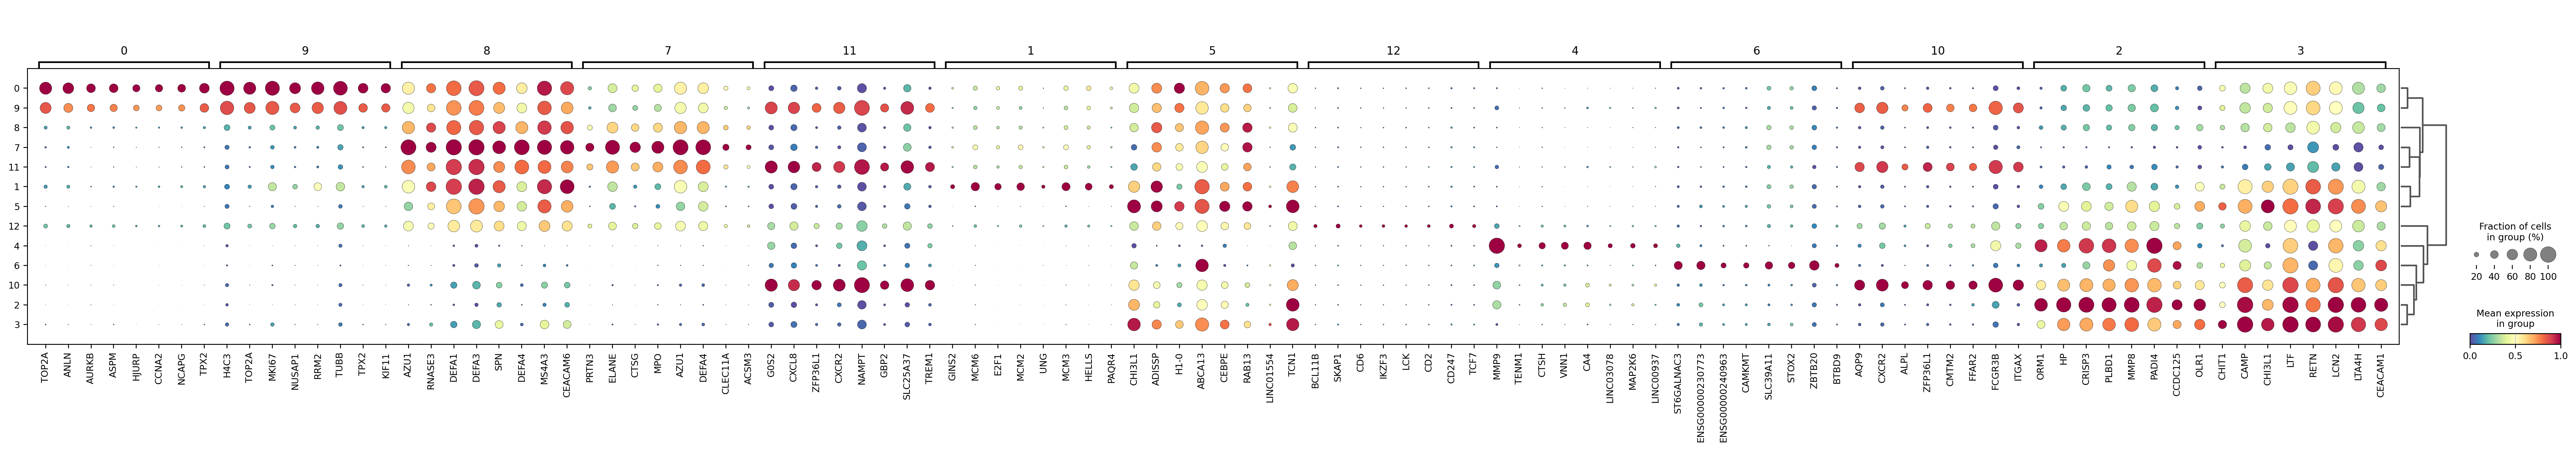

In [689]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [690]:
FeatureMatrix = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])

In [ ]:
%%R -i FeatureMatrix,R_data_path,groupby
source('GetEnrich.R')
GetEnrich(FeatureMatrix,plot_term_number = 10,R_data_path=R_data_path,groupby=groupby,
          gmtfile="/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/c2.cp.kegg_legacy.v2024.1.Hs.symbols.gmt")
#"/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/h.all.v2024.1.Hs.symbols.gmt"
#"/home/liyanguo/Marker/Immunity_PBMC.gmt"
#"/home/liyanguo/Marker/sepsis_PBMC.gmt"
#"/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/c5.go.bp.v2024.1.Hs.symbols.gmt"
#"/home/liyanguo/Marker/msigdb_v2024.1.Hs_GMTs/c2.cp.kegg_legacy.v2024.1.Hs.symbols.gmt"

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='MKI67',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='MPO',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adata, color='CD177',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)

sc.pl.umap(adata, color='PADI4',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[1,0],show=False)
sc.pl.violin(adata,'CEACAM8',groupby=groupby,show=False, ax=axs[1,1],size=0)
sc.pl.violin(adata,'CD33',groupby=groupby,show=False, ax=axs[1,2],size=0)
sc.pl.violin(adata,'ITGAM',groupby=groupby,show=False, ax=axs[1,3],size=0)
plt.show()

In [ ]:
sc.pl.violin(adt,'CD11c',groupby=groupby,layer='denoised_protein')

In [ ]:
sc.pl.violin(adata,'MMP9',groupby=groupby,size=0.1)

In [ ]:
sc.pl.dotplot(adata, ['MME','ANPEP','ITGAM','FCGR3B','CD33','MPO','KIT','CD34','HLA-DRA',
                      'FUT4','CR1','FUT3','B3GALT4','FCGR1A',
                      'S100A8','S100A9','S100A4','S100A6','S100A12',
                      'CEACAM8','MPO','MKI67','PADI4','CD177','CXCR2','CXCR4',
                      'SELL','ITGA4',
                      'TNFRSF4','NFKB1','CD44','ELANE',
                      'PRTN3','LTF','CHI3L1',
                     'PTPRC','MMP9','MMP8',
                      'CD44','CD33','OLFM4','TNFRSF9','CD86','BMAL1',
                      'DEFA1',
                      'ITGA4','FLT1','TNFRSF9','BTBD9'],standard_scale='none',
              groupby=groupby)

In [243]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_1
2     15459
7     13039
10    11274
5     10969
3      9895
4      9846
0      8562
11     5834
1      2355
9      2284
8      1900
6       850
12      675
Name: count, dtype: int64

In [244]:
#CD24+ CXCR4lo CEACAM8+ CD74+ ANPEP=CD13+ CD33- CD45RA-/PTPRC+ CD15+=FUT4

#immature: CD16- MME-
#mature: CD16+ MME+
#两条增殖轨迹

#PADI4 CD16 MKI67 MPO PADI4几个核心基因

cell_dict = {'Doublet|Lowquality':['12',#T marker
                                   '8',#ADT
                                   '6',],#BDBT9 ZBTB20等异常基因，低UMI
             #CD177 MMP9 MMP8 PADI4; https://www.biocompare.com/Editorial-Articles/577944-A-Guide-to-Neutrophil-Markers/

             #按照发育轨迹
             'Proliferative iLDNs':['0','1'],#MKI67 CEACAM8+
             'MPO+ CD177- iLDNs':['7',],#MPO ELANE PRTN3
             'MPO- CD177- iLDNs':['5',],
             'CD177int iLDNs':['3',],
             'MMP8+ CD177+ iLDNs':['2',],
             'MMP9+ CD177+ iLDNs':['4',],#晚幼粒细胞状态
             
             ##幼稚标志+成熟标志物，非双细胞；炎症情况下的左移
             ##CEACAM8+ CD16+ MME+ MPO+ SELL+
             #按照发育轨迹
             'Proliferative mLDNs':['9',],#CXCR2激活
             'MPO+ mLDNs':['11'],#CXCR2激活 MPO ELANE
             'MMP8+ CD177+ mLDNs':['10',],#CXCR2激活 MMP8
            }


#MPO,NE=ELANE,PAD4=PADI4,Gasdermin D=GSDMD,与中性粒NETs形成相关。

#maturation: ITGAM (CD11b), FCGR3A (CD16), and MME (CD10). https://www.nature.com/articles/s41590-023-01490-5

# https://www.biocompare.com/Editorial-Articles/577944-A-Guide-to-Neutrophil-Markers/
# https://www.biocompare.com/Editorial-Articles/594281-A-Guide-to-Granulocyte-Markers/
#  CD62Llow, CXCR2low, CXCR4hi, CD11bhi;
# upregulation of CXCR4 marks neutrophils for senescence;leading them back to the bone marrow for turnover.

#Degranulation, determined as an increase of the median fluorescent intensities (MFIs)
# of CD11b and CD66b;https://www.nature.com/articles/s41598-022-07455-2

#For mature, circulating neutrophils,
# a phenotype of CD16hi, CXCR2hi, CXCR4low, and CD62Lhi has been reported.
#在循环中，骨髓新释放的NM具有CD62L和CXCR2的高表达和CXCR4表达低的特点。

#Neutrophil profiling illuminates anti-tumor antigen-presenting potency

#黄来源：CD101区分成熟与否,但不适合

# https://www.nature.com/articles/s41590-024-02006-5 MMP9

In [245]:
check_dict_duplicates(cell_dict)

'无重复'

In [246]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [247]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    92942
Name: count, dtype: int64

In [248]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
MMP8+ CD177+ iLDNs     15459
MPO+ CD177- iLDNs      13039
MMP8+ CD177+ mLDNs     11274
MPO- CD177- iLDNs      10969
Proliferative iLDNs    10917
CD177int iLDNs          9895
MMP9+ CD177+ iLDNs      9846
MPO+ mLDNs              5834
Doublet|Lowquality      3425
Proliferative mLDNs     2284
Name: count, dtype: int64

In [249]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [250]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
MMP8+ CD177+ iLDNs     15459
MPO+ CD177- iLDNs      13039
MMP8+ CD177+ mLDNs     11274
MPO- CD177- iLDNs      10969
Proliferative iLDNs    10917
CD177int iLDNs          9895
MMP9+ CD177+ iLDNs      9846
MPO+ mLDNs              5834
Proliferative mLDNs     2284
Name: count, dtype: int64

In [251]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0589_Rep1_ACACGACC_TGGAACAA_CGGATTGC,CEACAM8+ Neutrophil,CEACAM8+ Neutrophil,Proliferative iLDNs,CEACAM8_Pos_Neutrophil c0,NaN,NaN,-2.389684,4.347318
D0589_Rep1_ACATTGGC_GACTAGTA_CAGATCTG,CEACAM8+ Neutrophil,CEACAM8+ Neutrophil,MMP8+ CD177+ iLDNs,CEACAM8_Pos_Neutrophil c2,NaN,NaN,8.011214,12.516145
D0589_Rep1_TGAAGAGA_AGTCACTA_CGCATACA,CEACAM8+ Neutrophil,CEACAM8+ Neutrophil,MPO+ CD177- iLDNs,CEACAM8_Pos_Neutrophil c7,NaN,NaN,0.420971,12.559570
D0589_Rep1_TATCAGCA_ACAGATTC_AGATGTAC,CEACAM8+ Neutrophil,CEACAM8+ Neutrophil,Proliferative mLDNs,CEACAM8_Pos_Neutrophil c9,NaN,NaN,0.565430,5.607220
D0864_M_Rep2_CCTCTATC_GAACAGGC_GAGCTGAA,CEACAM8+ Neutrophil,CEACAM8+ Neutrophil,MMP9+ CD177+ iLDNs,CEACAM8_Pos_Neutrophil c4,NaN,NaN,13.005115,10.134586


# 21. 定 CEACAM8_Neg_Neutrophil Refine

In [14]:
celltype="CEACAM8_Neg_Neutrophil"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [15]:
adata,adt,leiden_data = get_annotation_data(celltype)

... storing 'Celltype_L1_L2' as categorical
... storing 'Celltype_L1_L2_Refine' as categorical


In [16]:
groupby = "L3_leiden_TOTALVI_0.5"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [22]:
cell_index = celltypist.samples.downsample_adata(adata,mode = 'each', n_cells = 5000,
                                                 by = groupby,random_state=0)

In [23]:
adata_small = adata[cell_index].to_memory()

In [ ]:
sc.pp.normalize_total(adata_small)
sc.pp.log1p(adata_small)

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata_small, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata_small, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata_small, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata_small, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata_small, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata_small, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata_small, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata_small, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata_small, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata_small, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [ ]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
sc.pl.dotplot(adata_small, [
    'RGS2', 'G0S2', 'NFKBIA', 'CXCL8', 'FOS', 'GBP2', 'NFKBIZ', 'PPP1R15A', 'BCL2A1', 'IER2',
    'S100A4', 'EMP3', 'S100A6', 'RFLNB', 'ALOX5AP', 'FCN1', 'FOS', 'LYZ', 'FLNA', 'PADI4',
    'MALAT1', 'B2M', 'FTH1', 'PTPRC', 'SRGN', 'HLA-C', 'HLA-B', 'NAMPT', 'H3-3A', 'SAT1',
    'IGKC', 'RGS2', 'FOS', 'MT-CO1', 'CD74', 'HSPA5', 'H3-3A', 'ITM2B', 'S100A11',
    'S100A9', 'FTL', 'S100A8', 'ACTB', 'TMSB4X', 'FTH1', 'CSF3R', 'FCGR3B', 'S100A9',
    'MME', 'CXCL8', 'IFIT2', 'IFIT1', 'ALOX5AP', 'NFKBIZ', 'IFIT3', 'DUSP1', 'MNDA', 'JUNB',
    'TNFSF10', 'IFI16', 'IFIT2', 'IFIT1', 'RSAD2', 'IFIT3', 'GBP2', 'FCGR3B', 'MNDA', 'GBP1',
    'CD83', 'CAMK1D', 'SCLT1', 'DOCK4', 'PPCDC', 'ZFAND3', 'CHST11', 'SIK3',
    'FOS', 'S100A12', 'RGS2', 'ACSL1', 'S100A8', 'PROK2', 'S100A11', 'S100A9', 'G0S2', 'IFITM2',
    'CXCL8', 'NFKBIA', 'FOS', 'G0S2', 'IRF1', 'FTH1', 'DUSP1', 'JUNB', 'NFKBIZ', 'B2M',
    'GBP5', 'GBP2', 'MALAT1', 'NAMPT', 'B2M', 'PTPRC', 'HLA-B', 'IFITM3', 'CSF3R', 'HLA-C'],
             groupby=groupby,
             standard_scale='var',
             cmap='Spectral_r')

In [ ]:
sc.pl.violin(adata_small, keys='CD101', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0)

In [ ]:
sc.pl.violin(adata_small, keys='TNFRSF10C', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0)

In [ ]:
sc.pl.dotplot(adata_small, ['CD3D','IGHG4','CD274','GZMB','GNLY','CD79A','CD14',
                      ],groupby=groupby,standard_scale='group')

In [ ]:
sc.pl.dotplot(adata_small, ['CSF3R','CXCR2','CXCR4','RGS2','CXCL8','IFITM1','S100A4','S100A6',
                      'EMP3','S100A8','S100A9','S100A12','S100A11',
                      'FTL','MME','SELL',
                      'TNFSF10','IFI16','ISG15','CD83',
                      'FOS','CR1','ICAM1','IRF1','GBP1','GBP2','GBP5','IRF1',
                      'GSDMD','IL1R2','HAX1',
                       'MMP9','MMP8',
                       'MPO','CD177','PADI4','CHI3L1','MKI67','NT5E','ENG','HIF1A',
                            'IL1B','IL1R1','CCL2','CCL5','TNF','IL1A','IL1B'
                      ],groupby=groupby)

In [17]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
7     4644422
3     4443821
2     3732104
0     3514848
9     2945910
8     2453015
5     2199143
1     2197149
6     1364162
10     751555
4      435248
Name: count, dtype: int64

In [18]:
#都是CSF3R+(基本相同水平) CD11c+ SELL+/lo CD16+ CEACAM8- ISG15+/lo CR1+ ICAM1+
#都是CD49d- CXCR2+
#
cell_dict = {'Aged NDNs':['6',],#确认 CD16lo/- CD38- S100A8lo S100A9lo S100A12lo
             'CXCL8- NDNs':['5',],#MME+ CD16+ ITGAM+ ISG15hi TNFSF10 hi
             'IRF1- NDNs':['3',],#MME+ CD16+ ITGAM+ HLA HLB相对低表达
             'FOS- NDNs':['9',],#MME+
             'RGS2- NDNs':['8',],#MME+
             'Core NDNs':['0','1','2','4','7','10'],#有双胞的迹象
            }

#CD10 和 CD62L 高低不同，活化程度不同表型
# CD35 (CR1) 和 CD54  (ICAM-1)水平升高的成熟中性粒细胞



#G-CSF 暴露导致中性粒细胞前体 (SSChi CD33/CD66b+ CD38+ CD11c− CD10−) 和未成熟中性粒细胞 (SSChi CD33/CD66b+ CD38− CD11c−/+ CD10−) 数量增加

#CXCR2/CXCL8促进出骨髓，CXCR4抑制出骨髓
#C5AR1 FPR1 ADM

#maturation: ITGAM (CD11b), FCGR3A (CD16), and MME (CD10). https://www.nature.com/articles/s41590-023-01490-5

# https://www.biocompare.com/Editorial-Articles/577944-A-Guide-to-Neutrophil-Markers/
#  CD62Llow, CXCR2low, CXCR4hi, CD11bhi;upregulation of CXCR4 marks neutrophils for senescence;leading them back to the bone marrow for turnover.

#Degranulation, determined as an increase of the median fluorescent intensities (MFIs) of CD11b and CD66b;https://www.nature.com/articles/s41598-022-07455-2

#For mature, circulating neutrophils, a phenotype of CD16hi, CXCR2hi, CXCR4low, and CD62Lhi has been reported.

#Neutrophil profiling illuminates anti-tumor antigen-presenting potency

#黄来源：CD101区分成熟与否,但不适合

In [19]:
check_dict_duplicates(cell_dict)

'无重复'

In [20]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [21]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    28681377
Name: count, dtype: int64

In [22]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Core NDNs      15275326
IRF1- NDNs      4443821
FOS- NDNs       2945910
RGS2- NDNs      2453015
CXCL8- NDNs     2199143
Aged NDNs       1364162
Name: count, dtype: int64

In [23]:
adata.obs.loc[adata.obs['L3_leiden_TOTALVI_1']=='14','Celltype_L2_L3_Refine']='Doublet|Lowquality'

In [24]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [25]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Core NDNs      15230058
IRF1- NDNs      4442696
FOS- NDNs       2945066
RGS2- NDNs      2220135
CXCL8- NDNs     2198142
Aged NDNs       1363907
Name: count, dtype: int64

In [26]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine','receptor_type','receptor_type_BCR']]
indices.to_csv(f"{obj_path}/{celltype}/R2_refine_indices_{celltype}.csv")

# 22. 定 终 DC Refine

In [252]:
celltype="DC"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [253]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [254]:
groupby = "L3_leiden_TOTALVI_0.5"

In [339]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [490]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')#
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')#

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD14',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='CD79A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='CD3',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],layer='denoised_protein',show=False)

sc.pl.violin(adata,'CXCR4',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CSF3R',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'IL3RA',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adt,'CD14',groupby=groupby,show=False, ax=axs[1,3],size=0.5,layer='denoised_protein')#
plt.show()

In [ ]:
sc.pl.dotplot(adata, ['CD1C','CD2','CD14','FCER1A','VCAN','S100A9',
                      'SIGLEC10','SERPINA1','FCGR3A','S100A8',
                      'RTL1','FCGR1A',
                      'HLA-DRA','SIGLEC6','AXL','CLEC10A','ITGAM','ITGAX','ITGAE','CLEC9A','XCR1',
                      'BATF3','CD207','LAMP3','CCL19','CCR7',
                      'CLEC4C','JCHAIN','CD163','C5AR1','SIRPA','CD207','CD209','CD1A'],
              standard_scale='none',groupby=groupby)
#C5AR1=CD88

In [ ]:
sc.pl.violin(adata,'BTBD9',groupby=groupby)

In [255]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
2    119782
3     85385
5     85090
0      7780
4      5160
6      1897
1       178
Name: count, dtype: int64

In [256]:
cell_dict = {
             'ASDC':['4',],#SIGLEC6 AXL CLEC10A HAMP
             
             "pDCs":['5','6',],#

             "LAMP3+ DC":['1',],#
             
             'cDC1':['0'],#CLEC9A XCR1 BATF3
             'CD1C+ cDC2':['2',],# CLEC10A
    
             'CD14+ cDC2':['3',],#CLEC10A
            }
#cDC2 ,CD1C CLEC10A、IRF2、IRF4、RelB、RBP-J	人：CD11c, HLA-DR, CD1c (BDCA1), CD11b，FCER1A, CD2, CD172A, ILT1
#cDC1,XCR1 BATF3 IRF8, 人：CD11c, HLA-DR, CD141 (BCDA3) CLEC9A、CADM1、THBD 
#mo-DC体外诱导
# cDC2s (CD88−CD1c+CD2+CD163−, expressing or not CD5), DC3s (CD88−CD1c+CD2+CD163+, expressing or not CD14), and monocytes (CD88+CD14+CD163+), 
# A key issue is to distinguish DC3s from mo-DCs, as they display largely overlapping phenotypes (CD1c, FcεRI, and CD14) and transcriptomic signatures (CLEC10A, S100A8, S100A9, and VCAN).

In [257]:
check_dict_duplicates(cell_dict)

'无重复'

In [258]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [259]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    305272
Name: count, dtype: int64

In [260]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
CD1C+ cDC2    119782
pDCs           86987
CD14+ cDC2     85385
cDC1            7780
ASDC            5160
LAMP3+ DC        178
Name: count, dtype: int64

In [261]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0589_Rep1_AAGGTACA_TCTTCACA_CCTAATCC,Classical monocyte,cDC1,cDC1,DC c0,NaN,NaN,2.437860,-2.215032
D0589_Rep1_CACTTCGA_AAGGTACA_GCTCGGTA,Classical monocyte,cDC1,cDC1,DC c0,NaN,NaN,1.209162,-2.295565
D0589_Rep1_AGATGTAC_GTACGCAA_CGACTGGA,Classical monocyte,cDC1,cDC1,DC c0,NaN,NaN,1.112067,-2.005417
D0589_Rep1_GTACGCAA_CCTCCTGA_GCGAGTAA,Classical monocyte,cDC1,cDC1,DC c0,NaN,NaN,2.106997,-2.562344
D0864_M_Rep2_TATCAGCA_CGGATTGC_AAGAGATC,Classical monocyte,cDC1,cDC1,DC c0,NaN,NaN,2.153783,-2.723611


# 23. 定 终 Platelet Refine

In [262]:
celltype="Platelet"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [263]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [264]:
groupby = "L3_leiden_TOTALVI_0.5"

In [463]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [465]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')
sc.tl.dendrogram(adt,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [265]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.5
1    3102
4    1751
2    1579
0    1374
5    1008
6     374
3     120
Name: count, dtype: int64

In [266]:
cell_dict = {
             'Platelets':['0','1','2','5','6'],
             'Doublet|Lowquality':['4',
                        '3',],#BDBT9
            }

In [267]:
check_dict_duplicates(cell_dict)

'无重复'

In [268]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [269]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    9308
Name: count, dtype: int64

In [270]:
adata = adata[adata.obs['Celltype_L2_L3_Refine'] != "Doublet|Lowquality",:]

In [271]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Platelets    7437
Name: count, dtype: int64

In [272]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0213_Rep1_ATTGAGGA_ACAGCAGA_CGGATTGC,Platelet,Platelet,Platelets,Platelet c0,NaN,NaN,-2.174532,12.222096
D0213_Rep1_CGACTGGA_GCGAGTAA_AACCGAGA,Platelet,Platelet,Platelets,Platelet c1,NaN,NaN,0.490974,13.008471
D0213_Rep1_GAATCTGA_CCGTGAGA_AGAGTCAA,Platelet,Platelet,Platelets,Platelet c0,NaN,NaN,-2.913545,10.176146
D0110_E_Rep1_CCAGTTCA_AACAACCA_ACAGCAGA,Platelet,Platelet,Platelets,Platelet c6,NaN,NaN,-5.781617,9.562990
D0110_E_Rep1_AAACATCG_GAATCTGA_CAAGGAGC,Platelet,Platelet,Platelets,Platelet c1,NaN,NaN,0.278580,13.611465


# 24.  定 终 Mast Refine

In [273]:
celltype="Mast"
R_data_path = f"{obj_path}{celltype}"
sc.settings.figdir=f"{obj_path}{celltype}"

In [274]:
adata,adt,leiden_data = get_norm_annotation_data(celltype)

In [ ]:
sc.pl.umap(adata, color=['receptor_type','receptor_type_BCR'],
           frameon=False,
           legend_fontsize=4, legend_fontoutline=2,
           size=4,
           legend_loc='on data')

In [275]:
groupby = "L3_leiden_TOTALVI_0.1"

In [ ]:
xlsx = pd.ExcelWriter(f"{obj_path}{celltype}/{groupby}_freq_table.xlsx")
for group in ['SampleID', 'DonorID','scDblFinder.class',
              'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow',
              'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l2',
              'receptor_type',
              'receptor_type_BCR']:
    freq_table_multi = adata.obs.groupby([groupby, group]).size()
    pd.DataFrame(freq_table_multi).to_excel(xlsx,sheet_name=group)
xlsx.close()

In [ ]:
#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 12),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata, keys='nCount_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata, keys='percent_top50', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata, keys='percent_apop', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata, keys='percent_ribo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata, keys='percent_ieg', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata, keys='percent_oxphos', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata, keys='percent_hemo', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata, keys='G2M.Score', groupby=groupby, rotation=90,size=0.1,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
plt.savefig(f'{obj_path}{celltype}/{groupby}_TOTALVI_L3_metadata.png')

In [508]:
sc.tl.dendrogram(adata,groupby=groupby,use_rep='X_TOTALVI')

In [ ]:
#cosg差异
cosg.cosg(adata, key_added=f'cosg_{groupby}', groupby=groupby,
          mu=10,n_genes_user=100,remove_lowly_expressed=True,
         )
df_tmp = pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'])
df_tmp.to_csv(f"{obj_path}{celltype}/cosg_{groupby}.csv")
#cosg差异作图
df_tmp=pd.DataFrame(adata.uns[f'cosg_{groupby}']['names'][:8,]).T
df_tmp=df_tmp.reindex(adata.uns['dendrogram_'+groupby]['categories_ordered'])
marker_genes_list={idx: list(row.values) for idx, row in df_tmp.iterrows()}
marker_genes_list = {k: v for k, v in marker_genes_list.items() if not any(isinstance(x, float) for x in v)}
sc.pl.dotplot(adata, marker_genes_list,
             groupby=groupby,
             dendrogram=True,
             swap_axes=False,
             standard_scale='var',
             save=f'cosg_{groupby}',
             cmap='Spectral_r')

In [ ]:
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(16, 8))
sc.pl.umap(adata, color=groupby,legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,0],show=False)
sc.pl.umap(adata, color='CD69',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,1],show=False)
sc.pl.umap(adata, color='FCER1A',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,2],show=False)
sc.pl.umap(adt, color='HLA-DR',legend_fontsize=4, legend_fontoutline=2,size=1,legend_loc='on data',ax=axs[0,3],show=False)
#TNFAIP3/CXCR4/DDIT4/FOSL2/IRS2/BTG1/ZFP36/PNRC1/CDKN1B/PLIN2/BHLHE40/PLAUR/ETS1/DUSP1
#SELL/TXNIP/IFITM2/B2M/HLA-C

sc.pl.violin(adata,'TPSB2',groupby=groupby,show=False, ax=axs[1,0],size=0.5)
sc.pl.violin(adata,'CD34',groupby=groupby,show=False, ax=axs[1,1],size=0.5)
sc.pl.violin(adata,'KIT',groupby=groupby,show=False, ax=axs[1,2],size=0.5)
sc.pl.violin(adata,'NR4A2',groupby=groupby,show=False, ax=axs[1,3],size=0.5)#
plt.show()

In [ ]:
sc.pl.violin(adata,'IKZF2',groupby=groupby,size=0.5)#

In [276]:
adata.obs[groupby].value_counts()

L3_leiden_TOTALVI_0.1
0    1019
1     781
Name: count, dtype: int64

In [277]:
cell_dict = {
             'MC/MCP':['0','1'],
            }

In [278]:
check_dict_duplicates(cell_dict)

'无重复'

In [279]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(adata.obs[groupby]).isin(cell_dict[i])
    adata.obs.loc[ind,'Celltype_L2_L3_Refine'] = i

In [280]:
(adata.obs['Celltype_L2_L3_Refine'].isna()).value_counts()

Celltype_L2_L3_Refine
False    1800
Name: count, dtype: int64

In [281]:
adata.obs['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
MC/MCP    1800
Name: count, dtype: int64

In [282]:
indices = adata.obs.loc[:,['Celltype_L1_L2','Celltype_L1_L2_Refine','Celltype_L2_L3_Refine',groupby,'receptor_type','receptor_type_BCR']]
indices['UMAP_1'] = adata.obsm['X_umap'][:, 0].copy()
indices['UMAP_2'] = adata.obsm['X_umap'][:, 1].copy()
indices.rename(columns={groupby: 'leiden_cluster'}, inplace=True) #Save the cluster categorical, check the relationship between clusters and clinical to avoid missing someone.
indices['leiden_cluster'] = celltype + " c" + indices['leiden_cluster'].astype(str)
os.makedirs(f'{finnal_path}/{celltype}', exist_ok=True)
indices.to_csv(f"{finnal_path}/{celltype}/Finnal_indices_{celltype}.csv")
indices.head()

,Celltype_L1_L2,Celltype_L1_L2_Refine,Celltype_L2_L3_Refine,leiden_cluster,receptor_type,receptor_type_BCR,UMAP_1,UMAP_2
D0864_M_Rep2_GGTGCGAA_AATGTTGC_CCTAATCC,HSPC,Mast,MC/MCP,Mast c0,NaN,NaN,6.815987,-1.549557
D0864_M_Rep2_ACACAGAA_AGCACCTC_GACAGTGC,HSPC,Mast,MC/MCP,Mast c0,NaN,NaN,10.599508,-1.562321
D0378_Rep2_AAGGACAC_TGAAGAGA_TCCGTCTA,HSPC,Mast,MC/MCP,Mast c1,NaN,NaN,0.997147,0.623506
D0144_Rep2_CGCATACA_AGCACCTC_GAATCTGA,HSPC,Mast,MC/MCP,Mast c1,NaN,NaN,-0.600594,5.418881
D0130_Rep1_CTGAGCCA_GCTCGGTA_GCCAAGAC,HSPC,Mast,MC/MCP,Mast c0,NaN,NaN,3.785555,0.790119


# 合并所有数据

In [33]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

In [34]:
try:
    del indices_dict,combined_indices,Finnal_indices_dict,combined_Finnal_indices_dict,Processing_combined_indices
except:
    print("It is None!")

It is None!


## 终版

In [35]:
celltypes=['Basophil','CEACAM8_Pos_Neutrophil',
           #'CEACAM8_Neg_Neutrophil',
           'DC','HSPC',
           'iNKT','Mast','Monocyte','NK',
           'Non_NK_ILC','Plasma','Platelet',
]

In [36]:
Finnal_indices_dict= []
for i in tqdm(celltypes):
    indices = pd.read_csv(f'{finnal_path}{i}/Finnal_indices_{i}.csv',index_col=0)
    Finnal_indices_dict.append(indices)

100%|██████████████████████████████████████████| 11/11 [00:11<00:00,  1.03s/it]


In [37]:
combined_Finnal_indices_dict = pd.concat(Finnal_indices_dict)

In [38]:
combined_Finnal_indices_dict['Celltype_L2_L3_Refine'].value_counts()
#合计

Celltype_L2_L3_Refine
Core classical monocytes     2402622
Adaptive NK cells            2352029
CD56dim NK cells             2312983
Non-classical monocytes       510244
GBP1+ classical monocytes     360407
Intermediate monocytes        303118
CD56bright NK cells           219168
CD1C+ cDC2                    119782
pDCs                           86987
CD14+ cDC2                     85385
Proliferative NK cells         37728
Basophils                      34204
IGKChi Plasma cells            29084
MMP8+ CD177+ iLDNs             15459
MPO+ CD177- iLDNs              13039
MMP8+ CD177+ mLDNs             11274
MPO- CD177- iLDNs              10969
Proliferative iLDNs            10917
ILCP                            9928
CD177int iLDNs                  9895
MMP9+ CD177+ iLDNs              9846
cDC1                            7780
ILC2                            7634
Platelets                       7437
HSC/MPP                         6807
MPO+ mLDNs                      5834
CLP             

## 过程

In [28]:
celltypes=['NaiveB',
           'MemoryB',
           
           'CEACAM8_Neg_Neutrophil',
           
           'NaiveCD4',
           'Treg',
           'CD4_helper_memory',
           'CytotoxicCD4',

           'NaiveCD8',
           'CD8Tcm',
           'TemCD8',
           
           'MAIT',
           'gdT',
          ]

In [29]:
%%bash
ls /home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R2/ | wc -l
ls /home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R2/*/R2_refine* | wc -l
ls /home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Finnal/ | wc -l

23
12
33


In [30]:
indices_dict= []
for i in tqdm(celltypes):
    indices = pd.read_csv(f'{obj_path}{i}/R2_refine_indices_{i}.csv',index_col=0)
    indices_dict.append(indices)

100%|██████████████████████████████████████████| 12/12 [00:51<00:00,  4.27s/it]


In [31]:
Processing_combined_indices = pd.concat(indices_dict)

In [39]:
combined_indices = pd.concat([Processing_combined_indices,combined_Finnal_indices_dict])

In [40]:
combined_indices['Celltype_L1_L2'].isna().value_counts()

Celltype_L1_L2
False    52921668
Name: count, dtype: int64

In [41]:
combined_indices['Celltype_L1_L2_Refine'].isna().value_counts()

Celltype_L1_L2_Refine
False    52921668
Name: count, dtype: int64

In [42]:
combined_indices['Celltype_L2_L3_Refine'].isna().value_counts()

Celltype_L2_L3_Refine
False    52921668
Name: count, dtype: int64

In [43]:
combined_indices['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Core NDNs                    15230058
IRF1- NDNs                    4442696
Tem CD8+ T                    3886082
Naïve CD4+ T                  3040683
FOS- NDNs                     2945066
Core classical monocytes      2402622
Adaptive NK cells             2352029
CD56dim NK cells              2312983
RGS2- NDNs                    2220135
CXCL8- NDNs                   2198142
Helper memory CD4+ T          1921373
Aged NDNs                     1363907
Naïve CD8+ T                  1357566
Cytotoxic CD4+ T              1150706
Naïve B                       1036706
Vδ2 T                          778168
Treg                           724779
Memory B                       711801
Non-classical monocytes        510244
GBP1+ classical monocytes      360407
MAIT                           335429
Intermediate monocytes         303118
CD56bright NK cells            219168
Th22                           130188
CD1C+ cDC2                     119782
Th2                         

## save

In [45]:
def save_to_indices(celltype,celltype_to_file):
    L2_refine_path_R3 = '/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Level2_Refine_R3'
    indices=combined_indices['Celltype_L2_L3_Refine'].isin(celltype)
    indices_celltype=combined_indices[indices]
    print(f"{indices_celltype['Celltype_L2_L3_Refine'].value_counts()}")
    os.makedirs(f'{L2_refine_path_R3}/{celltype_to_file}', exist_ok=True)
    indices_celltype.to_csv(f"{L2_refine_path_R3}/{celltype_to_file}/R3_indices_{celltype_to_file}.csv")

In [46]:
Processing_combined_indices['Celltype_L2_L3_Refine'].value_counts()

Celltype_L2_L3_Refine
Core NDNs               15230058
IRF1- NDNs               4442696
Tem CD8+ T               3886082
Naïve CD4+ T             3040683
FOS- NDNs                2945066
RGS2- NDNs               2220135
CXCL8- NDNs              2198142
Helper memory CD4+ T     1921373
Aged NDNs                1363907
Naïve CD8+ T             1357566
Cytotoxic CD4+ T         1150706
Naïve B                  1036706
Vδ2 T                     778168
Treg                      724779
Memory B                  711801
MAIT                      335429
Th22                      130188
Th2                        91976
Atypical memory B          79242
Temra CD8+ T               74549
Tcm CCR4+ CD8+ T           57815
Th1/Th17                   33006
Vδ1 T                      27606
Proliferative T            27150
Tcm CCR4- CD8+ T           19968
CD56+ γδ T                 11460
Dn T                        7521
Name: count, dtype: int64

In [47]:
save_to_indices(celltype=['Core NDNs','IRF1- NDNs','FOS- NDNs','RGS2- NDNs','CXCL8- NDNs','Aged NDNs'],celltype_to_file='CEACAM8_Neg_Neutrophil')

Celltype_L2_L3_Refine
Core NDNs      15230058
IRF1- NDNs      4442696
FOS- NDNs       2945066
RGS2- NDNs      2220135
CXCL8- NDNs     2198142
Aged NDNs       1363907
Name: count, dtype: int64


In [101]:
save_to_indices(celltype=['Atypical memory B'],celltype_to_file='AtypicalB')
save_to_indices(celltype=['Memory B'],celltype_to_file='Memory_B')
save_to_indices(celltype=['Naïve B'],celltype_to_file='NaiveB')

Celltype_L2_L3_Refine
Atypical memory B    79242
Name: count, dtype: int64
Celltype_L2_L3_Refine
Memory B    711801
Name: count, dtype: int64
Celltype_L2_L3_Refine
Naïve B    1036706
Name: count, dtype: int64


In [104]:
save_to_indices(celltype=['Dn T'],celltype_to_file='DnT')

Celltype_L2_L3_Refine
Dn T    7521
Name: count, dtype: int64


In [156]:
save_to_indices(celltype=['MAIT',],celltype_to_file='MAIT')

Celltype_L2_L3_Refine
MAIT    335429
Name: count, dtype: int64


In [157]:
save_to_indices(celltype=['Vδ2 T','CD56+ γδ T','Vδ1 T'],celltype_to_file='gdT')

Celltype_L2_L3_Refine
Vδ2 T         778168
Vδ1 T          27606
CD56+ γδ T     11460
Name: count, dtype: int64


In [158]:
save_to_indices(celltype=['Proliferative T'],celltype_to_file='ProliferativeT')

Celltype_L2_L3_Refine
Proliferative T    27150
Name: count, dtype: int64


In [159]:
save_to_indices(celltype=['Treg'],celltype_to_file='Treg')
save_to_indices(celltype=['Naïve CD4+ T'],celltype_to_file='NaiveCD4')
save_to_indices(celltype=['Helper memory CD4+ T','Th1/Th17',
                          'Th22','Th2'],
                celltype_to_file='CD4_helper_memory')
save_to_indices(celltype=['Cytotoxic CD4+ T'],celltype_to_file='CytotoxicCD4')

Celltype_L2_L3_Refine
Treg    724779
Name: count, dtype: int64
Celltype_L2_L3_Refine
Naïve CD4+ T    3040683
Name: count, dtype: int64
Celltype_L2_L3_Refine
Helper memory CD4+ T    1921373
Th22                     130188
Th2                       91976
Th1/Th17                  33006
Name: count, dtype: int64
Celltype_L2_L3_Refine
Cytotoxic CD4+ T    1150706
Name: count, dtype: int64


In [124]:
save_to_indices(celltype=['Naïve CD8+ T'],celltype_to_file='NaiveCD8')
save_to_indices(celltype=['Tem CD8+ T','Temra CD8+ T'],celltype_to_file='TemCD8')
save_to_indices(celltype=['Tcm CCR4- CD8+ T','Tcm CCR4+ CD8+ T'],celltype_to_file='CD8Tcm')

Celltype_L2_L3_Refine
Naïve CD8+ T    1357566
Name: count, dtype: int64
Celltype_L2_L3_Refine
Tem CD8+ T      3886082
Temra CD8+ T      74549
Name: count, dtype: int64
Celltype_L2_L3_Refine
Tcm CCR4+ CD8+ T    57815
Tcm CCR4- CD8+ T    19968
Name: count, dtype: int64
